# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
!pip install h3
import h3
import matplotlib.patches as mpatches

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results

### Urban green spaces data 
Data is from 'Open Data Austria', obtained through *Riepl et. al (2025)*

In [3]:
file_name = 'data/OEFFGRUENFLOGD.json'
gdf_green = gpd.read_file(file_name)
print(gdf_green.head(3))
print(gdf_green.columns)

                    id  OBJECTID       TEXT13ID F_TYP               T_TEXT  \
0  OEFFGRUENFLOGD.2289      2289  Währinger Pa*     L       Währinger Park   
1  OEFFGRUENFLOGD.2290      2290  Türkenschanz*     L    Türkenschanzplatz   
2  OEFFGRUENFLOGD.2291      2291    Kongreßpark     L  Kongreßpark/Kainzga   

              T_LANG  O       P  O_UEREG  O_REGION  ...  Q_GRI  Q_HUN  Q_BAB  \
0     Währinger Park  1  100000        0         0  ...      0      1      0   
1  Türkenschanzplatz  1       1        0         0  ...      0      0      0   
2         Kainzgasse  1  100000        0         0  ...      0      1      0   

   Q_WC  Q_SPO  Q_TRB       UMFANG       FLAECHE  SE_ANNO_CAD_DATA  \
0     1   1245      1  1460.941451  57020.131903              None   
1     0      0      0   310.900196   2002.715993              None   
2     2     12      1   249.284876   3243.484789              None   

                                            geometry  
0  MULTIPOLYGON (((16.35083 48

In [4]:
gdf_green = gdf_green.rename(columns={
    'UMFANG': 'circumference',
    'FLAECHE': 'area'
})

gdf_green = gdf_green[['id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area', 'geometry']]
print(gdf_green.columns)

Index(['id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area',
       'geometry'],
      dtype='object')


## District level data
### Some social and economic data for each census district of Vienna
Data in census district scale is obtained by *Riepl et. al (2025)*

In [5]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2

districts = districts.rename(columns={
    'UMFANG': 'circumference',
    'FLAECHE': 'area'
})

districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,STATAUSTR0,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,91301.0,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,91501.0,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,90701.0,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."


In [6]:
gdf_census = gpd.read_file('data/data_ssi.geojson')
gdf_census

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((16.37903 48.21187, 16.37902 48.21188..."
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((16.37906 48.20748, 16.37882 48.20755..."
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((16.36893 48.20072, 16.36905 48.20072..."
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,"POLYGON ((16.36326 48.2039, 16.36383 48.20424,..."
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,"POLYGON ((16.36765 48.21307, 16.36843 48.21273..."
...,...,...,...,...,...,...,...,...
241,2315,1.267620,2.076986,1.032159,0.955199,1.604961,5,"POLYGON ((16.26417 48.15314, 16.26433 48.1532,..."
242,2316,-0.038446,0.315260,0.839466,0.834993,0.412143,4,"POLYGON ((16.23894 48.15341, 16.23821 48.15312..."
243,2317,-0.410833,0.503589,0.921774,1.088109,0.406096,4,"POLYGON ((16.37712 48.14752, 16.37708 48.14753..."
244,2318,-1.138054,-0.177753,-0.123182,0.210761,-0.470587,2,"POLYGON ((16.34062 48.1487, 16.34051 48.14871,..."


In [7]:
# Spatial join in order to find socio-economic indicators in district scale as well. 
# This will be used later on to understand whether i can use average income as a proxy for rental prices or not.

gdf_census = gdf_census.to_crs(districts.crs)

# Attaching district info to each census district
gdf_joined = gpd.sjoin(gdf_census, districts[['geometry', 'NAMEK_NUM']], how='left', predicate='intersects')

# Group by district name and taking the average
socio_vars = ['avg_income', 'unemprate', 'university_share', 'benefit_share', 'SSI']  # all socio-economic variables
district_stats = gdf_joined.groupby('NAMEK_NUM')[socio_vars].mean().reset_index()
district_stats.rename(columns={
    'avg_income': 'district_avgincome',
    'unemprate': 'district_unemprate',
    'university_share': 'district_univshare',
    'benefit_share': 'district_benefitshare',
    'SSI': 'district_SSI'
}, inplace=True)

districts = districts.merge(district_stats, on='NAMEK_NUM', how='left')

In [8]:
districts.head()

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry,district_avgincome,district_unemprate,district_univshare,district_benefitshare,district_SSI
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651...",0.642256,0.369003,0.549082,0.285477,0.561803
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ...",-0.591063,-0.260053,0.175842,-0.071401,-0.214924
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849...",0.409909,0.407823,1.101009,0.588805,0.743321
3,Landstraße,3.0,III,"3., Landstraße",III. Landstraße,LANDSTRASSE,III.,03,1030.0,903.0,...,7.403038e+06,13961.80,2023-07-18,13129.0,"POLYGON ((16.39662 48.20739, 16.39678 48.20656...",0.272875,0.113722,0.570711,0.249346,0.379246
4,Josefstadt,8.0,VIII,"8., Josefstadt",VIII. Josefstadt,JOSEFSTADT,VIII.,08,1080.0,908.0,...,1.089946e+06,4170.30,2023-07-18,13130.0,"POLYGON ((16.34915 48.21516, 16.35099 48.21497...",0.604907,0.663846,1.374317,0.706087,0.985625


### Data for blue spaces and administrative boundaries
Data is from OpenStreetMap

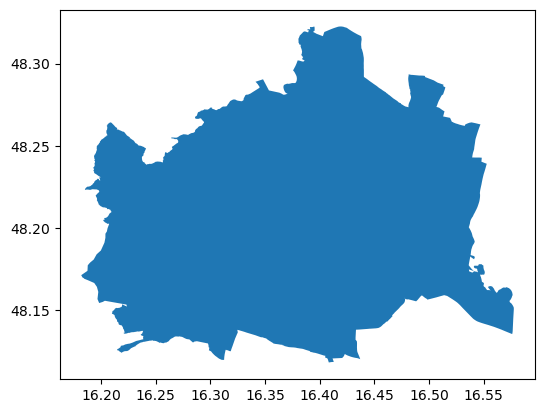

In [9]:
admin_city = ox.geocode_to_gdf('Vienna')
admin_city.plot()
plt.show()

**Blue spaces** are "Outdoor environments—natural or manmade—that prominently feature water, and are accessible and offer opportunities for recreation, relaxation, or aesthetic appreciation." (According to the World Health Organization (WHO) and related research (e.g., BlueHealth project))

This includes:
- Oceans and seas
- Rivers, lakes, ponds
- Canals, streams
- Urban fountains, reservoirs (if accessible)
- Wetlands (if part of nature/recreation areas)

They exclude:
- Wastewater facilities
- Industrial drainage systems
- Hidden/underground pipes
- Non-recreational, restricted areas (e.g. dams, treatment plants)


In [10]:
pip install osmnx==1.9.3

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Define the polygon for the administrative 
admin_poly = admin_city.geometry.values[0]


# Download POIs for blue spaces within the administrative boundary
tags_blue = {
    'natural': ['water', 'wetland'],
    'waterway': ['stream', 'river', 'canal'],
    'water': ['pond', 'lake', 'reservoir', 'basin', 'fishpond']
}
blue = ox.features_from_polygon(admin_poly, tags=tags_blue)

print("Water sources:", len(blue))
print("Type of data:", type(blue))
blue.head(3)

Water sources: 2207
Type of data: <class 'geopandas.geodataframe.GeoDataFrame'>


source  \
element_type osmid                 
node         6813960988      NaN   
way          3870590     landsat   
             3870688     landsat   

                                                                  geometry  \
element_type osmid                                                           
node         6813960988                          POINT (16.41034 48.13083)   
way          3870590     POLYGON ((16.49867 48.27628, 16.4991 48.27635,...   
             3870688     POLYGON ((16.42203 48.23973, 16.42207 48.23983...   

                        created_by odbl river:waterway_distance waterway  \
element_type osmid                                                         
node         6813960988        NaN  NaN                     NaN      NaN   
way          3870590           NaN  NaN                     NaN      NaN   
             3870688           NaN  NaN                     NaN      NaN   

                        seamark:type                 name maxwidth obstacle  \
element_type osmid                                                            
node         6813960988          NaN                  NaN      NaN      NaN   
way          3870590             NaN  Transportbetongrube      NaN      NaN   
             3870688             NaN     Schießstattlacke      NaN      NaN   

                         ... year_of_construction toilets:wheelchair memorial  \
element_type osmid       ...                                                    
node         6813960988  ...                  NaN                NaN      NaN   
way          3870590     ...                  NaN                NaN      NaN   
             3870688     ...                  NaN                NaN      NaN   

                        fence_type abandoned  lit ways attraction name:sh  \
element_type osmid                                                          
node         6813960988        NaN       NaN  NaN  NaN        NaN     NaN   
way          3870590           NaN       NaN  NaN  NaN        NaN     NaN   
             3870688           NaN       NaN  NaN  NaN        NaN     NaN   

                        species:wikidata  
element_type osmid                        
node         6813960988              NaN  
way          3870590                 NaN  
             3870688                 NaN  

[3 rows x 134 columns]

epsg:4326


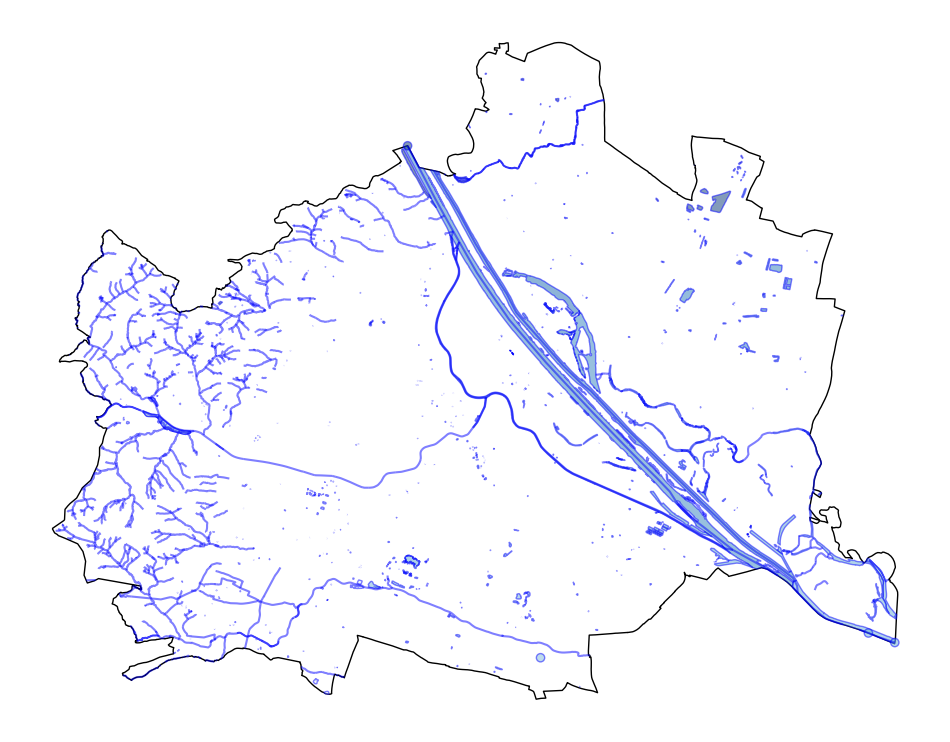

In [12]:
blue_clipped = gpd.clip(blue, admin_city)
print(blue_clipped.crs)
# Create a plot to visualize the admin boundary and blue spaces
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
blue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()

## Visualizations

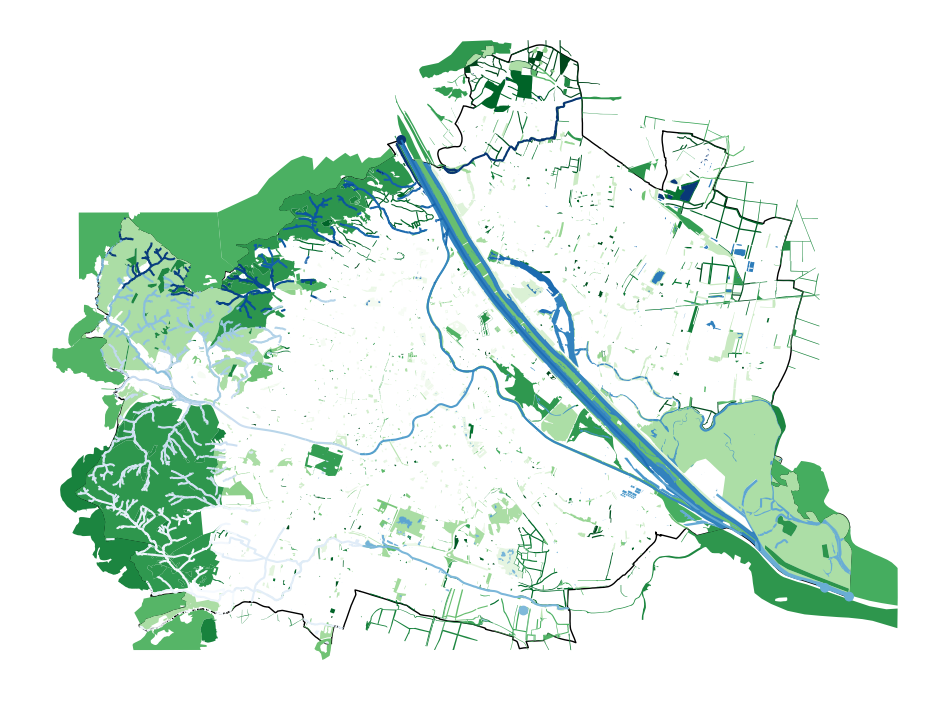

In [13]:
#greens from Open Data Austria, and blues from OSM:

f, ax = plt.subplots(1, 1, figsize=(12, 12))

admin_city.plot(ax=ax, color='none', edgecolor='k')
gdf_green.plot(ax=ax, cmap='Greens')
blue_clipped.plot(ax=ax, cmap='Blues')
ax.axis('off')

plt.savefig("output/vienna_green_blue_map.png", dpi=300, bbox_inches='tight')
plt.show()

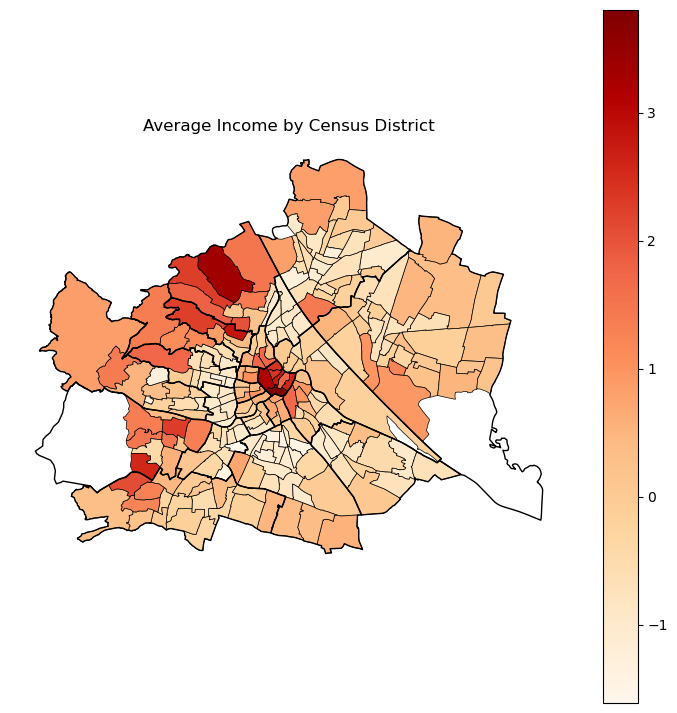

In [14]:
# Plot average income by census district (Zahlbezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='avg_income',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Average Income by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

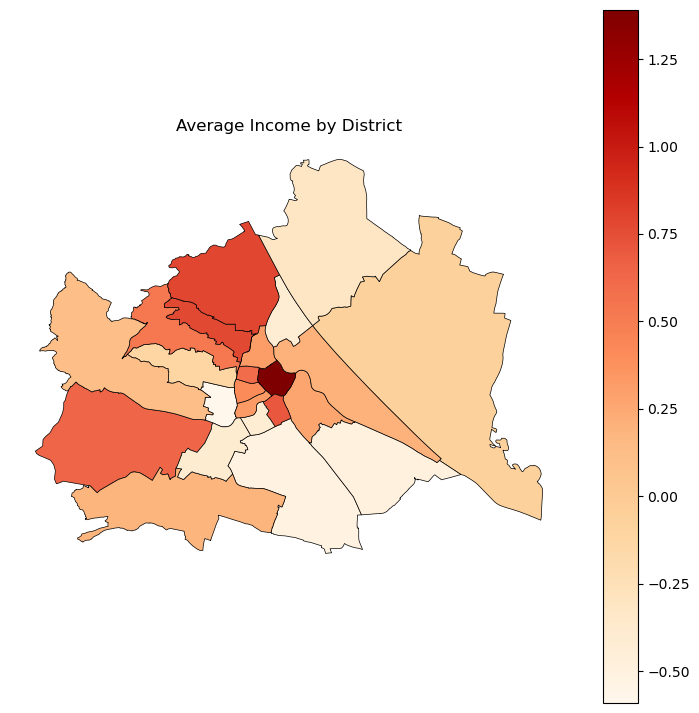

In [15]:
# Plot average income by district (Bezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

districts.plot(
    column='district_avgincome',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
#districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Average Income by District", fontsize=12)
ax.axis('off')

plt.savefig("output/district_avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

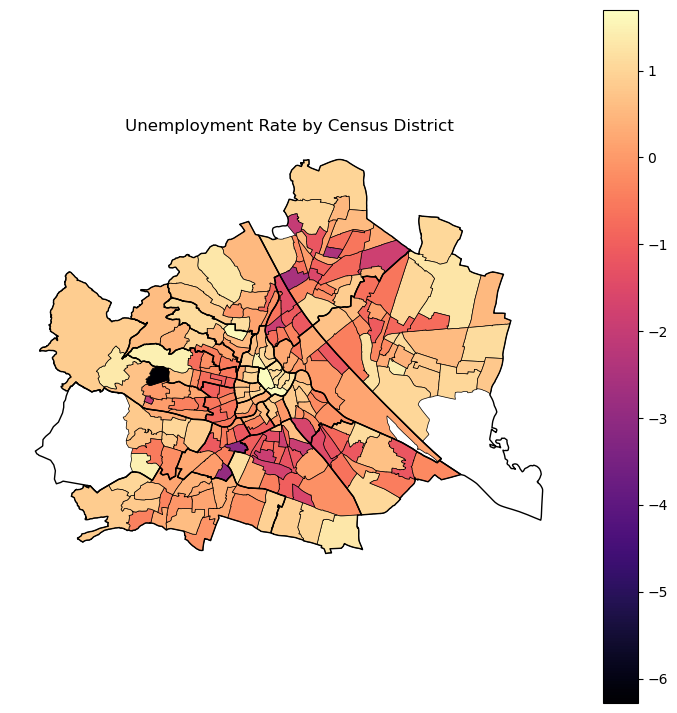

In [16]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='unemprate',      
    cmap='magma',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Unemployment Rate by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/unemp_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

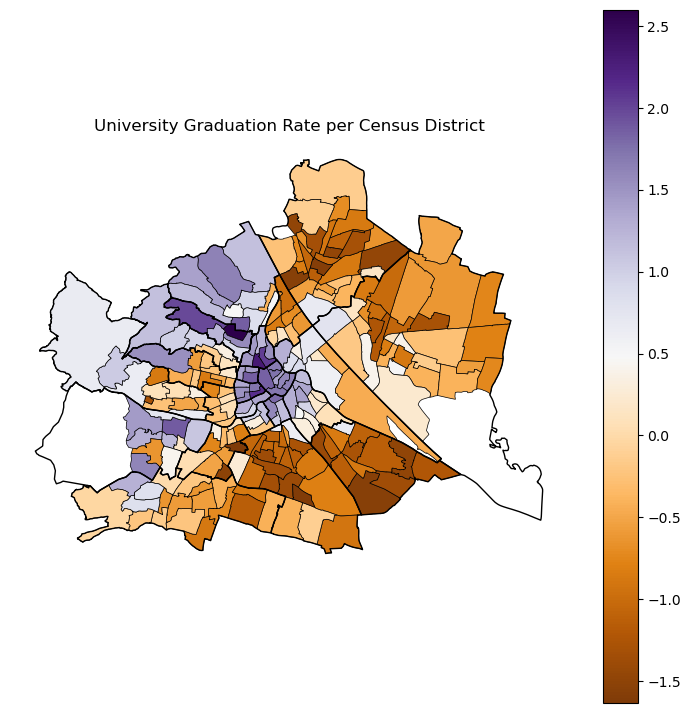

In [17]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='university_share',     
    cmap='PuOr',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,             
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("University Graduation Rate per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/uni_grad_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

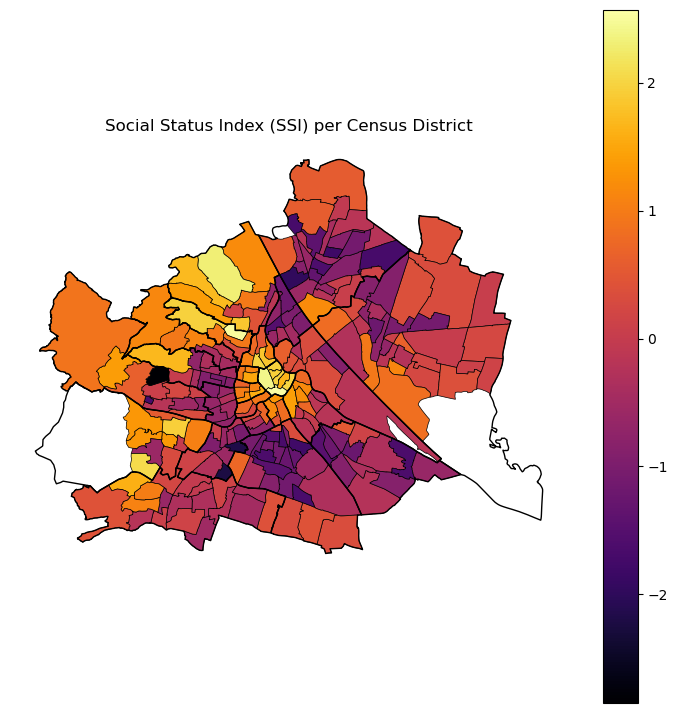

In [18]:
# Plot SSI by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='SSI',      
    cmap='inferno',              
    linewidth=0.5,           
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Social Status Index (SSI) per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

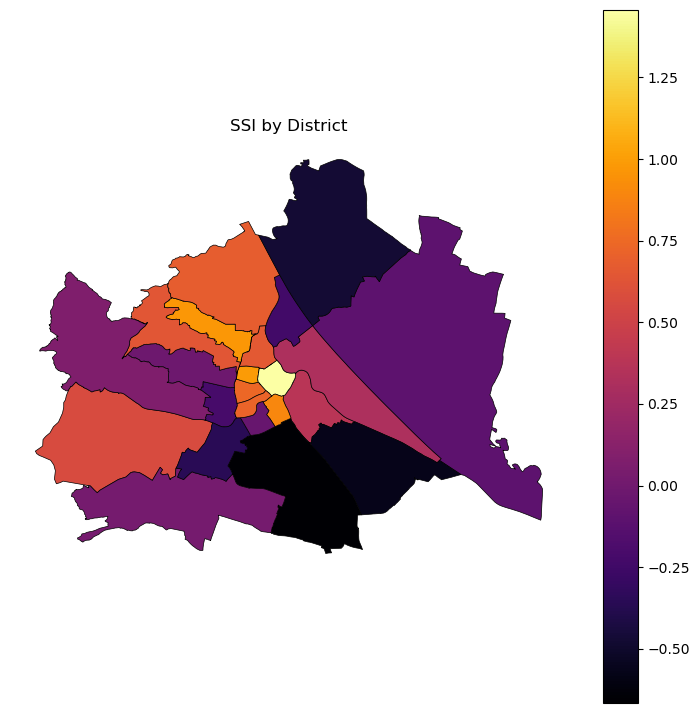

In [19]:
# Plot SSI by district (Bezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

districts.plot(
    column='district_SSI',     
    cmap='inferno',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
#districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("SSI by District", fontsize=12)
ax.axis('off')

plt.savefig("output/district_ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

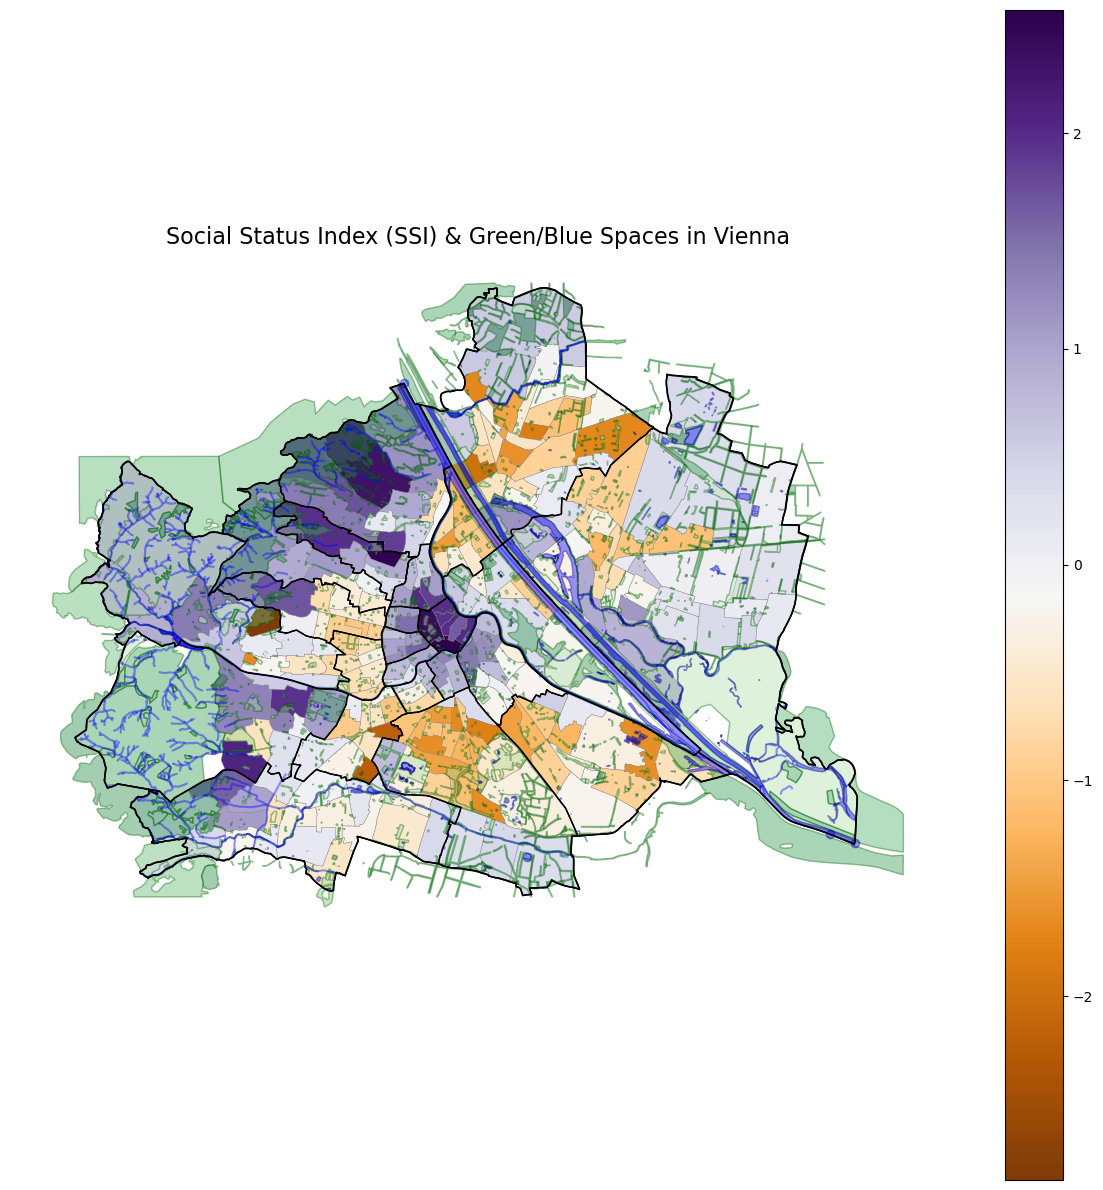

In [20]:
# Plot everything together
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot SSI as choropleth
gdf_census.plot(
    column='SSI',
    cmap='PuOr',     
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Overlay green and blue spaces
gdf_green.plot(ax=ax, cmap='Greens', alpha=0.4, edgecolor='darkgreen') #austrian governmental data
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue') #OSM data

# Overlaying district boundaries, and city boundaries
admin_city.plot(ax=ax, color='none', edgecolor='black', linewidth=1.2)
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Tidy up
ax.set_title("Social Status Index (SSI) & Green/Blue Spaces in Vienna", fontsize=16)
ax.axis('off')

plt.tight_layout()

plt.savefig("output/ssi_ubgs_map.png", dpi=300, bbox_inches='tight')
plt.show()


## Correlation

* How much green/blue space overlap in each census district?
* Does the existence of green/blue spaces correlated with social status index (SSI)?

In [21]:
# epsg 4326 is coordinates, and not good for area and periphery calculations. 
# need to change their crs. Target crs: epsg=31256

gdf_census = gdf_census.to_crs(epsg=31256)
gdf_green = gdf_green.to_crs(epsg=31256)
admin_city = admin_city.to_crs(epsg=31256)
blue = blue.to_crs(epsg=31256)

In [22]:
print(gdf_green.geometry.type.unique())
print(blue.geometry.type.unique())

# in order to overlay, I need same types of geometries
# seperate blue geometries into 2 different gdf: blue_lines, blue_areas

# Separate blue space geometries by type
blue_areas = blue[blue.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
blue_lines = blue[blue.geometry.type.isin(['LineString', 'MultiLineString'])].copy()

print(blue_areas.geometry.type.unique())
print(blue_lines.geometry.type.unique())

['MultiPolygon' 'Polygon']
['Point' 'Polygon' 'LineString' 'MultiPolygon']
['Polygon' 'MultiPolygon']
['LineString']


In [23]:
# Choose a reasonable buffer (in meters)
blue_lines_buffered = blue_lines.copy()
blue_lines_buffered['geometry'] = blue_lines_buffered.to_crs(epsg=31256).buffer(10)  # ~10m width
blue_lines_buffered = blue_lines_buffered.to_crs(blue.crs)  # return to original CRS

# Combine with actual polygons
blue_areas_total = pd.concat([blue_areas, blue_lines_buffered], ignore_index=True)
blue_areas_total.head(3)

,source,geometry,created_by,odbl,river:waterway_distance,waterway,seamark:type,name,maxwidth,obstacle,...,year_of_construction,toilets:wheelchair,memorial,fence_type,abandoned,lit,ways,attraction,name:sh,species:wikidata
0,landsat,"POLYGON ((12361.826 348671.604, 12393.61 34867...",NaN,NaN,NaN,NaN,NaN,Transportbetongrube,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,landsat,"POLYGON ((6677.263 344598.658, 6680.698 344609...",NaN,NaN,NaN,NaN,NaN,Schießstattlacke,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,"POLYGON ((6275.055 344535.063, 6275.568 344534...",NaN,NaN,NaN,NaN,NaN,Irissee,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# green areas per district
green_clipped = gpd.clip(gdf_green, admin_city)
green_in_census = gpd.overlay(gdf_census, green_clipped, how='intersection', keep_geom_type=False)
green_in_census['green_area'] = green_in_census.geometry.area
print(green_in_census.columns.tolist())

['ZBEZ', 'university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile', 'id', 'OBJECTID', 'T_TEXT', 'T_LANG', 'circumference', 'area', 'geometry', 'green_area']


In [25]:
# blue areas per district
blue_in_census = gpd.overlay(gdf_census, blue_areas_total, how='intersection')
blue_in_census['blue_area'] = blue_in_census.geometry.area
blue_in_census.head(3)

# 1. Get shared columns
common_cols = list(set(green_in_census.columns) & set(blue_in_census.columns))
print("Shared columns:", common_cols)

# 2. Optionally exclude the join key (e.g. 'ZBEZ') and geometry
cols_to_drop = [col for col in common_cols if col not in ['ZBEZ', 'geometry']]

# 3. Drop shared columns from blue_in_census before merge
blue_in_census_cleaned = blue_in_census.drop(columns=cols_to_drop)

# 4. Merge
ugbs_census = green_in_census.merge(blue_in_census_cleaned, on='ZBEZ', how='left')
#print(ugbs_census.columns.tolist())
ugbs_census_clean = ugbs_census[['ZBEZ', 'university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile', 'geometry_x', 'geometry_y', 'green_area', 'blue_area']]
ugbs_census_clean.head(7)

Shared columns: ['SSI', 'university_share', 'area', 'ZBEZ', 'avg_income', 'geometry', 'quintile', 'unemprate', 'benefit_share']


,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry_x,geometry_y,green_area,blue_area
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3497.002 341023.556, 3494.089 341024...","POLYGON ((3129.491 340896.774, 3129.5 340894.7...",37.380483,16.971625
1,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3486.189 341497.846, 3487.929 341497...","POLYGON ((3129.491 340896.774, 3129.5 340894.7...",1139.371257,16.971625
2,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","POLYGON ((3489.529 340479.256, 3489.436 340479...",69635.658363,30534.074489
3,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","POLYGON ((3647.063 340872.424, 3645.249 340872...",69635.658363,154.568715
4,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","MULTIPOLYGON (((3848.419 341493.166, 3848.819 ...",69635.658363,3.237957
5,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","POLYGON ((3546.629 340731.249, 3548.672 340733...",69635.658363,3415.834089
6,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"MULTIPOLYGON (((3696.979 340797.926, 3696.649 ...","POLYGON ((3917.428 341441.163, 3910.658 341398...",69635.658363,21793.319908


In [26]:
# Step 1: Drop duplicate geometries per ZBEZ for green areas
green_unique = ugbs_census_clean[['ZBEZ', 'geometry_x', 'green_area']].drop_duplicates(subset=['ZBEZ', 'geometry_x'])
green_agg = green_unique.groupby('ZBEZ')['green_area'].sum().reset_index()
green_agg.rename(columns={'green_area': 'green_area_sum'}, inplace=True)

# Step 2: Do the same for blue areas
blue_unique = ugbs_census_clean[['ZBEZ', 'geometry_y', 'blue_area']].drop_duplicates(subset=['ZBEZ', 'geometry_y'])
blue_agg = blue_unique.groupby('ZBEZ')['blue_area'].sum().reset_index()
blue_agg.rename(columns={'blue_area': 'blue_area_sum'}, inplace=True)

# Step 3: Get socio-economic variables (they're identical per ZBEZ)
socio_vars = ['university_share', 'avg_income', 'unemprate', 'benefit_share', 'SSI', 'quintile']
socio_agg = ugbs_census_clean.groupby('ZBEZ')[socio_vars].first().reset_index()

# Step 4: Merge all into one final GeoDataFrame
ugbs_census_final = socio_agg.merge(green_agg, on='ZBEZ', how='left').merge(blue_agg, on='ZBEZ', how='left')
ugbs_census_final.head(5)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,green_area_sum,blue_area_sum
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,1176.751740,16.971625
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,77668.038665,58683.051370
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,25070.979682,20255.527374
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,213339.041684,944.004931
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,17608.835553,0.000000


In [27]:
# Ensure CRS is projected in meters before area calculation
gdf_census = gdf_census.to_crs(epsg=31287)

# Compute area in square meters and convert to square kilometers
gdf_census['census_area_m2'] = gdf_census.geometry.area
gdf_census['census_area_km2'] = gdf_census['census_area_m2'] / 1e6

# Keep only needed columns and merge
area_df = gdf_census[['ZBEZ', 'census_area_km2']]
ugbs_census_final = ugbs_census_final.merge(area_df, on='ZBEZ', how='left')

ugbs_census_final['green_ratio'] = ugbs_census_final['green_area_sum'] / 1e6 / ugbs_census_final['census_area_km2']
ugbs_census_final['blue_ratio'] = ugbs_census_final['blue_area_sum'] / 1e6 / ugbs_census_final['census_area_km2']
ugbs_census_final[['green_ratio', 'blue_ratio']] = ugbs_census_final[['green_ratio', 'blue_ratio']].round(4)

In [28]:
ugbs_census_final.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,green_area_sum,blue_area_sum,census_area_km2,green_ratio,blue_ratio
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,1176.751740,16.971625,0.377356,0.0031,0.0000
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,77668.038665,58683.051370,0.379174,0.2048,0.1548
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,25070.979682,20255.527374,0.465247,0.0539,0.0435


In [29]:
#COMMENT FOR FUTURE: DO IT BY EXCLUDING INNERE STADT. IT HAS HIGH SSI, BUT HISTROICAL BUILDINGS LESS UBGS
# Correlation matrix
corr_matrix = ugbs_census_final[['SSI', 'green_ratio', 'blue_ratio']].corr()
print(corr_matrix)

                  SSI  green_ratio  blue_ratio
SSI          1.000000     0.204112   -0.008174
green_ratio  0.204112     1.000000    0.380436
blue_ratio  -0.008174     0.380436    1.000000


In [30]:
import statsmodels.api as sm

# Prepare data
X = ugbs_census_final[['university_share', 'avg_income', 'unemprate', 'benefit_share', 'green_ratio', 'blue_ratio']]
X = sm.add_constant(X)  # adds intercept term
A = ugbs_census_final[['university_share', 'avg_income', 'unemprate', 'benefit_share']]
A = sm.add_constant(A)  # adds intercept term
B = ugbs_census_final[['green_ratio', 'blue_ratio' ]]
B = sm.add_constant(B)  # adds intercept term
y = ugbs_census_final['SSI']

# Fit model
model = sm.OLS(y, X).fit()
model2 =sm.OLS(y, A).fit()
model3 =sm.OLS(y, B).fit()
print(model.summary())
print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    SSI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.179e+31
Date:                Fri, 09 May 2025   Prob (F-statistic):               0.00
Time:                        16:25:20   Log-Likelihood:                 7933.4
No. Observations:                 244   AIC:                        -1.585e+04
Df Residuals:                     237   BIC:                        -1.583e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             1.518e-17   1.55e-16  

In [31]:
# Prepare data
X = ugbs_census_final['SSI']
X = sm.add_constant(X)  # adds intercept term
y = ugbs_census_final[['green_ratio']]

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            green_ratio   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     10.52
Date:                Fri, 09 May 2025   Prob (F-statistic):            0.00135
Time:                        16:25:20   Log-Likelihood:                 136.32
No. Observations:                 244   AIC:                            -268.6
Df Residuals:                     242   BIC:                            -261.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1097      0.009     12.330      0.0

## Introduction of housing data into the analysis

* Data is from Statistiks Austria. 
* Does the existence of green/blue spaces affect the housing prices in that district?
* If they affect, can we check how it changes with proximity of housing to green/blue space?

In [32]:
# !pip install odfpy pandas
# Load ODS file and list all sheet names
housing_path = "data/SpecialEvaluation.ods" 
housing_data = pd.read_excel(housing_path, engine="odf", sheet_name=None)

# Show available sheets
print(housing_data.keys())

dict_keys(['Apartment_Prices', 'House_Prices', 'Building_Plots', 'Federal_Provinces', 'Apartment_Prices_municipalities', 'House_Prices_municipalities', 'Fed__states_and_constr__Periods'])


In [33]:
housing_data = pd.read_excel(
    housing_path,
    engine="odf",
    sheet_name="Apartment_Prices",  
    header=1                        # use row 2 as column names
)
housing_data.columns

Index(['D. CD.', 'Districts', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023],
      dtype='object')

In [34]:
# Keep only Vienna rows, Wiener Neustadt is not in Vienna in terms of state boundaries
housing_vienna = housing_data[
    housing_data['Districts'].str.contains('Wien', na=False) &
    ~housing_data['Districts'].str.contains('Wiener Neustadt', na=False)
]
housing_vienna.columns = housing_vienna.columns.astype(str)

housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()
housing_vienna.head(5)

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_29385/2484245388.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()


,D. CD.,Districts,2015,2016,2017,2018,2019,2020,2021,2022,2023,district_clean
93,901,"Wien 1.,Innere Stadt",6569,7861,9368,10955,11186,10947,13078,14389,12733,Innere Stadt
94,902,"Wien 2.,Leopoldstadt",3650,4125,4327,4482,4590,5215,5331,6181,5494,Leopoldstadt
95,903,"Wien 3.,Landstraße",3934,4039,4483,4787,4375,5483,5715,5850,5635,Landstraße
96,904,"Wien 4.,Wieden",4189,4237,4932,5195,5650,5586,6471,7776,6646,Wieden
97,905,"Wien 5.,Margareten",3272,3500,3548,3662,3796,4634,5648,5440,4562,Margareten


In [35]:
# Merging housing prices data into districts GeoDataFrame
housing_districts = districts.merge(
    housing_vienna[['district_clean', '2015', '2016', '2017', '2018', '2019', '2020',  '2021', '2022', '2023']],
    left_on='NAMEK',
    right_on='district_clean',
    how='left'
)

year_cols = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
housing_districts['avg_price_years'] = housing_districts[year_cols].mean(axis=1)
housing_districts['avg_price_years'] = housing_districts['avg_price_years'].round(2)

In [36]:
pd.set_option('display.precision', 2)
housing_districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4232,4132,4043,4423,4462,4821,5593,6159,5327,4799.11
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,2429,3369,3315,3827,3860,4111,4729,4460,4215,3812.78
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4774,4553,4755,5405,5833,6043,6332,6336,5929,5551.11


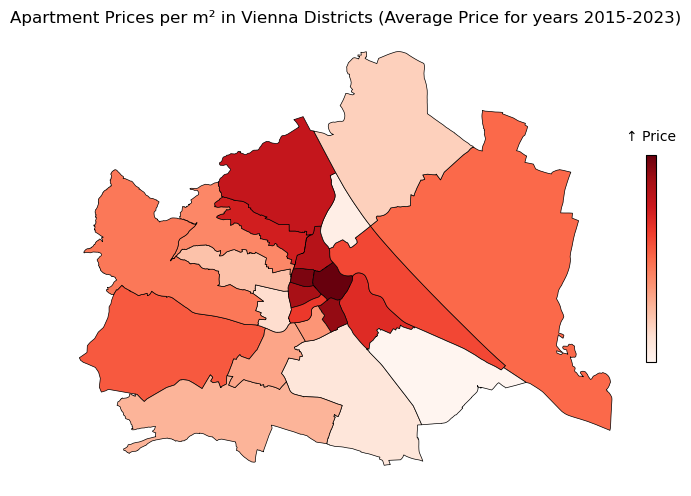

In [37]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot without legend
housing_districts_plot = housing_districts.plot(
    column='avg_price_years',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False 
)

# Create a scalar mappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=housing_districts['avg_price_years'].min(),
    vmax=housing_districts['avg_price_years'].max()
)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm._A = []  # required for matplotlib <3.1

# Adding the colorbar manually
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.3,              
    pad=0.01,                
    orientation='vertical',
    location='right'         
)

# Remove ticks and add title to the colorbar
cbar.ax.set_yticks([])
cbar.ax.set_title('↑ Price', fontsize=10, pad=10)

# Final plot tweaks
ax.set_title("Apartment Prices per m² in Vienna Districts (Average Price for years 2015-2023)", fontsize=12)
ax.axis('off')
plt.show()

In [38]:
green_clipped = green_clipped.to_crs(districts.crs)
blue_clipped = blue_clipped.to_crs(districts.crs)

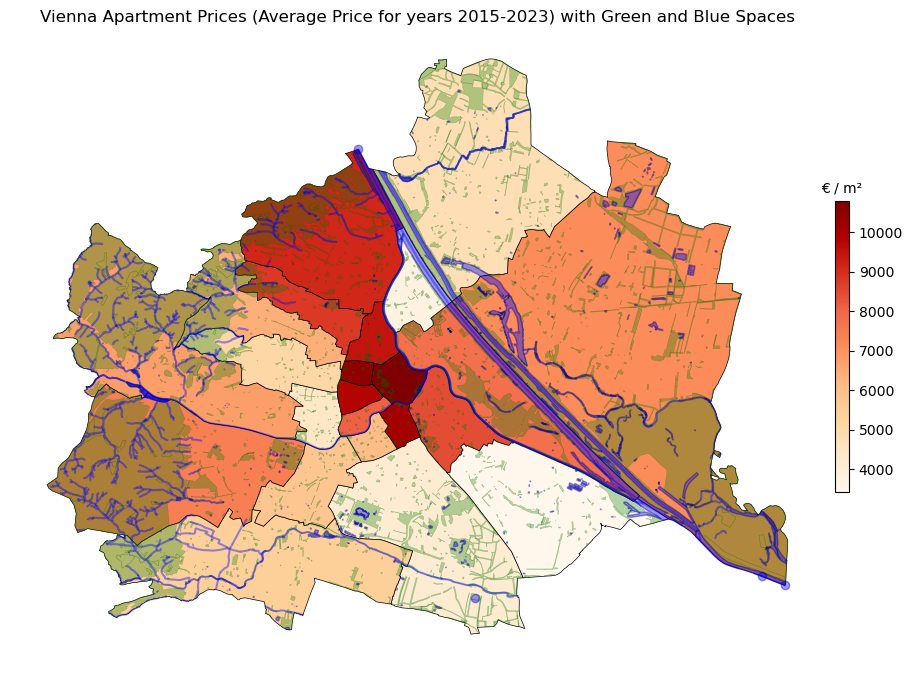

In [39]:
# Setup plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot housing prices as base choropleth
housing_districts.plot(
    column='avg_price_years',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False  
)

# Overlay green and blue spaces
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Add colorbar manually
norm = mpl.colors.Normalize(vmin=housing_districts['avg_price_years'].min(), vmax=housing_districts['avg_price_years'].max())
sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.01)
cbar.ax.set_title('€ / m²', fontsize=10)

# Title & layout
ax.set_title("Vienna Apartment Prices (Average Price for years 2015-2023) with Green and Blue Spaces", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()


## Correlation of housing prices 
### * with average income per district over the years
### * with UGBS

* Is there a correlation between the amount of green/blue space a district has and their average housing price per m2? Using average income as proxy

In [40]:
print(gdf_census.crs)
print(housing_districts.crs)

EPSG:31287
EPSG:4326


In [41]:
housing_districts = housing_districts.to_crs(gdf_census.crs)
print(housing_districts.crs)

EPSG:31287


In [42]:
census_with_district = gpd.sjoin(
    gdf_census,
    housing_districts[['district_clean', 'geometry']],  # keep only name + geometry of Bezirke
    how='left',
    predicate='intersects'
)

census_with_district.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,census_area_m2,census_area_km2,index_right,district_clean
0,0101,1.60,1.74,1.13,1.12,1.65,5,"POLYGON ((626295.39 483610.523, 626294.825 483...",377355.80,0.38,8,Leopoldstadt
0,0101,1.60,1.74,1.13,1.12,1.65,5,"POLYGON ((626295.39 483610.523, 626294.825 483...",377355.80,0.38,5,Innere Stadt
1,0102,1.65,2.57,1.24,1.14,2.00,5,"POLYGON ((626317.026 483122.065, 626298.952 48...",379174.18,0.38,3,Landstraße


In [43]:
# Aggregate total green/blue values per main district
green_blue_summary = census_with_district.groupby('district_clean')[
    ['green_ratio', 'blue_area_ratio', 'blue_length_km']
].sum().reset_index()

green_blue_summary.head(3)

KeyError: "Columns not found: 'blue_area_ratio', 'blue_length_km', 'green_ratio'"

In [ ]:
# Merge green/blue summary into housing districts
districts_full = housing_districts.merge(
    green_blue_summary,
    on='district_clean',
    how='left'
)

print(districts_full.columns)
districts_full.head(3)

In [ ]:
# Correlation matrix
districts_full[['2023', 'green_ratio', 'blue_area_ratio', 'blue_length_km']].corr()

In [ ]:
import statsmodels.api as sm

ubgs = districts_full[['green_ratio', 'blue_area_ratio', 'blue_length_km']]
print(ubgs.dtypes)
price = districts_full['2023']

In [ ]:
# Convert all columns to numeric (force errors to NaN)
ubgs = ubgs.apply(pd.to_numeric, errors='coerce')
price = pd.to_numeric(price, errors='coerce')

print(ubgs.isna().sum())   # NaNs in predictors
print(price.isna().sum())  # NaNs in outcome variable

In [ ]:
model = sm.OLS(price, ubgs).fit()
print(model.summary())

### What if we do the OLS with log-log transformation? 

According to McCord et al (2024), log-log transformation might work better due to its computational efficiency and interpretability. 
It would be better to include neighboruhood attributes, structural characteristics, green and blue spaces attributes. 

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Select variables
ubgs = districts_full[['green_ratio', 'blue_area_ratio', 'blue_length_km']].copy()
price = districts_full['2023'].copy()

# Replace 0 with NaN to avoid log(0) errors
ubgs.replace(0, np.nan, inplace=True)
price.replace(0, np.nan, inplace=True)

# Drop rows with any NaNs before log-transforming
model_df = ubgs.copy()
model_df['price'] = price
model_df = model_df.dropna()
model_df['price'] = pd.to_numeric(model_df['price'], errors='coerce')

# Apply log transformation
X_log = np.log(model_df[['green_ratio', 'blue_area_ratio', 'blue_length_km']])
y_log = np.log(model_df['price'])

# Add constant (intercept term)
X_log = sm.add_constant(X_log)

# Fit log-log model
model_log = sm.OLS(y_log, X_log).fit()

# Print summary
print(model_log.summary())


In [ ]:
# Predict log(price) from the model
y_pred_log = model_log.predict(X_log)

# Plot actual vs predicted (log-log scale)
plt.figure(figsize=(7, 7))
plt.scatter(y_pred_log, y_log, color='darkblue', alpha=0.7)

# Plot 45-degree line (perfect prediction)
plt.plot([y_log.min(), y_log.max()], [y_log.min(), y_log.max()], 'r--', label='Perfect Prediction')

plt.xlabel("Predicted log(price)")
plt.ylabel("Actual log(price)")
plt.title("Log-Log Regression Fit: Predicted vs Actual log(Price)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

features = ['green_ratio', 'blue_area_ratio', 'blue_length_km']
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(features):
    axs[i].scatter(np.log(model_df[var]), y_log, color='dodgerblue', alpha=0.7)
    axs[i].set_xlabel(f'log({var})')
    axs[i].set_ylabel('log(price)' if i == 0 else '')
    axs[i].set_title(f'log(price) vs log({var})')
    axs[i].grid(True)

plt.suptitle('Log-Log Relationships: Apartment Price vs Green/Blue Space', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## OTHER TRIAL FOR UGBS - PRICE - INCOME CORRELATION

In [44]:
districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,area,circumference,AKT_TIMEST,SE_SDO_ROW,geometry,district_avgincome,district_unemprate,district_univshare,district_benefitshare,district_SSI
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,3.77e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651...",0.64,0.37,0.55,0.29,0.56
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3.92e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ...",-0.59,-0.26,0.18,-0.07,-0.21
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,1.61e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849...",0.41,0.41,1.10,0.59,0.74


In [45]:
ugbs_census_final.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,green_area_sum,blue_area_sum,census_area_km2,green_ratio,blue_ratio
0,0101,1.60,1.74,1.13,1.12,1.65,5,1176.75,16.97,0.38,3.10e-03,0.00
1,0102,1.65,2.57,1.24,1.14,2.00,5,77668.04,58683.05,0.38,2.05e-01,0.15
2,0103,1.71,3.81,1.64,1.23,2.57,5,25070.98,20255.53,0.47,5.39e-02,0.04


In [46]:
housing_districts.head(3)

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,avg_price_years
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4232,4132,4043,4423,4462,4821,5593,6159,5327,4799.11
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,2429,3369,3315,3827,3860,4111,4729,4460,4215,3812.78
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4774,4553,4755,5405,5833,6043,6332,6336,5929,5551.11


### Steps
- After observing main dataframes i have, decided to first use 'districts' and 'housing_districts' dfs.
- Through these 2 df, I will check the correlation of average income over 2015 to 2023, and average apartment price over the same years
- If they are highly correlated, then I can conclude that I will use census district level average income data as a proxy for rental prices. 


In [47]:
# Correlation matrix
# Combine the two columns into one DataFrame
soc_econ_price_df = pd.DataFrame({
    'avg_income': districts['district_avgincome'],
    'unemp_rate':districts['district_unemprate'],
    'univ_share':districts['district_univshare'],
    'benefit_share':districts['district_benefitshare'],
    'district_SSI':districts['district_SSI'],
    'avg_price': housing_districts['avg_price_years']
})

# Compute correlation
income_price_corr = soc_econ_price_df.corr().loc['avg_income', 'avg_price']
ssi_price_corr = soc_econ_price_df.corr().loc['district_SSI', 'avg_price']
print("Correlation:", income_price_corr.round(3))
print("Correlation:", ssi_price_corr.round(3))


Correlation: 0.782
Correlation: 0.768


In [48]:
# Step 1: Select only relevant columns
plot_df = soc_econ_price_df[['avg_income', 'district_SSI', 'avg_price']].copy()

# Step 2: Convert all to numeric (in case something was parsed as object)
plot_df = plot_df.apply(pd.to_numeric, errors='coerce')

# Step 3: Drop any rows with NaNs
plot_df = plot_df.dropna()

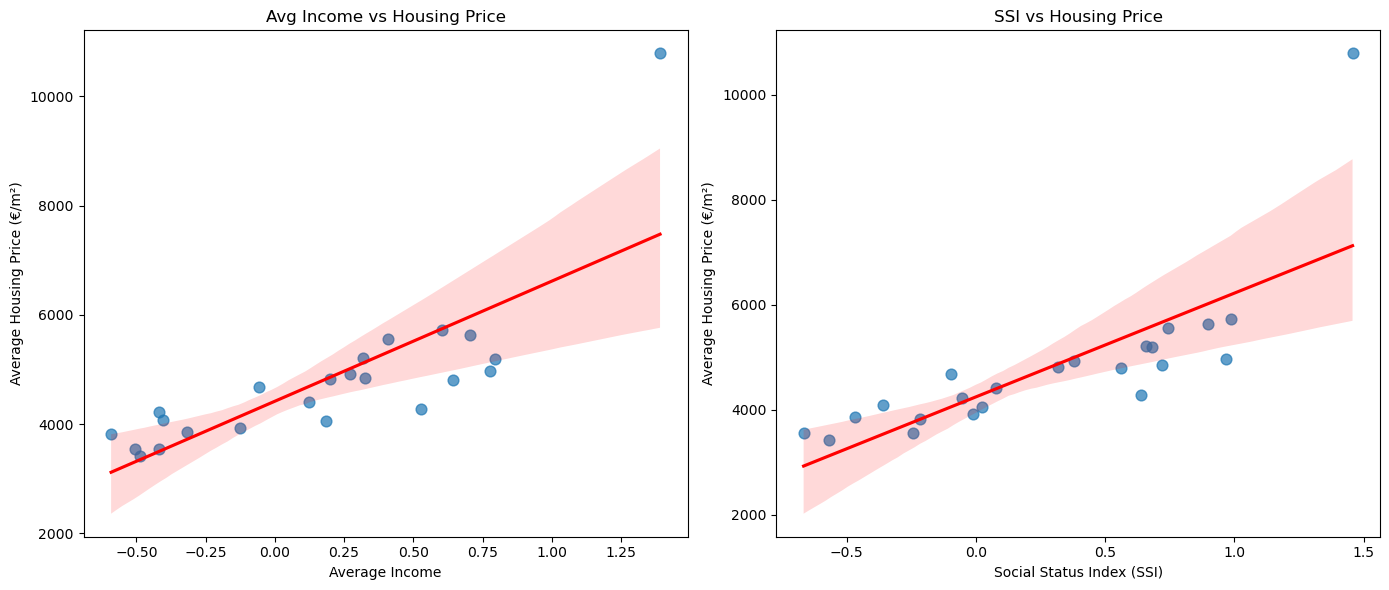

In [50]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# avg_income vs avg_price
sns.regplot(
    data=plot_df,
    x='avg_income',
    y='avg_price',
    ax=axes[0],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[0].set_title('Avg Income vs Housing Price')
axes[0].set_xlabel('Average Income')
axes[0].set_ylabel('Average Housing Price (€/m²)')

# district_SSI vs avg_price
sns.regplot(
    data=plot_df,
    x='district_SSI',
    y='avg_price',
    ax=axes[1],
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'color': 'red'}
)
axes[1].set_title('SSI vs Housing Price')
axes[1].set_xlabel('Social Status Index (SSI)')
axes[1].set_ylabel('Average Housing Price (€/m²)')

plt.tight_layout()
plt.show()


* As these correlation amounts indicate, property prices are highly correlated with average income and SSI.
* Because they are highly correlated, I can use census level average income data as a proxy to rental prices. Thus, testing H3.
#### H3: As in higher value properties, people with higher taxable income are tend to live, H1 can be evolved as people with higher income levels tend to habit closer to urban green and blue spaces correlating negatively with distance to them.

# WHO theory

In [48]:
# all residential buildings
residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace', 'semidetached_house', ]}
residential = ox.features_from_place('Vienna, Austria', tags=residential_tags)

print("Number of residential buildings:", len(residential))
residential.head()

Number of residential buildings: 66768


geometry addr:city addr:country  \
element id                                                             
node    3050128807   POINT (16.45262 48.2404)      Wien           AT   
        3191378969  POINT (16.28469 48.18459)      Wien           AT   
        3191378970  POINT (16.28475 48.18473)      Wien           AT   
        3220013168   POINT (16.47623 48.2135)      Wien           AT   
        3220013171  POINT (16.47638 48.21381)      Wien           AT   

                   addr:housenumber addr:postcode         addr:street  \
element id                                                              
node    3050128807              NaN          1220       Pogrelzstraße   
        3191378969               39          1130  Münichreiterstraße   
        3191378970               41          1130  Münichreiterstraße   
        3220013168              7/5          1220      Stavangergasse   
        3220013171              7/1          1220      Stavangergasse   

                   at_bev:addr_date     building source name  ... community  \
element id                                                    ...             
node    3050128807              NaN  residential    NaN  NaN  ...       NaN   
        3191378969              NaN  residential    NaN  NaN  ...       NaN   
        3191378970              NaN  residential    NaN  NaN  ...       NaN   
        3220013168              NaN        house    NaN  NaN  ...       NaN   
        3220013171              NaN        house    NaN  NaN  ...       NaN   

                   community:de community:en community:fr community:gender  \
element id                                                                   
node    3050128807          NaN          NaN          NaN              NaN   
        3191378969          NaN          NaN          NaN              NaN   
        3191378970          NaN          NaN          NaN              NaN   
        3220013168          NaN          NaN          NaN              NaN   
        3220013171          NaN          NaN          NaN              NaN   

                   community:it roof:type former:name building:height  \
element id                                                              
node    3050128807          NaN       NaN         NaN             NaN   
        3191378969          NaN       NaN         NaN             NaN   
        3191378970          NaN       NaN         NaN             NaN   
        3220013168          NaN       NaN         NaN             NaN   
        3220013171          NaN       NaN         NaN             NaN   

                   addr:interpolation  
element id                             
node    3050128807                NaN  
        3191378969                NaN  
        3191378970                NaN  
        3220013168                NaN  
        3220013171                NaN  

[5 rows x 251 columns]

In [49]:
# City-wide Vienna boundary from districts
vienna_boundary = districts.unary_union
vienna_gdf = gpd.GeoDataFrame(geometry=[vienna_boundary], crs=districts.crs)

# Clean geometry and reproject everything to a common projected CRS (EPSG:31256)
residential = residential[residential.is_valid & ~residential.is_empty]
gdf_green = gdf_green[gdf_green.is_valid & ~gdf_green.is_empty]

crs_proj = 31256
vienna_gdf_proj = vienna_gdf.to_crs(epsg=crs_proj)
residential_proj = residential.to_crs(epsg=crs_proj)
green_proj = gdf_green.to_crs(epsg=crs_proj)

# Clip residential and green areas to Vienna boundary
residential_vienna = gpd.clip(residential_proj, vienna_gdf_proj)
green_vienna = gpd.clip(green_proj, vienna_gdf_proj)

# Calculate centroids of residential buildings
res_centroids = residential_vienna.copy()
res_centroids['geometry'] = res_centroids.centroid

# Calculate distances to nearest green space
green_union = unary_union(green_vienna.geometry)
res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

# Output stats
total = len(res_centroids)
within = res_centroids['within_300m'].sum()
percent = (within / total) * 100 if total > 0 else 0

print("WHO 300m Rule for Vienna:")
print(f"Total residential buildings: {total}")
print(f"Within 300m of green space: {within}")
print(f"Percentage compliant with WHO guideline: {percent:.2f}%")

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_48132/2199168617.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vienna_boundary = districts.unary_union


WHO 300m Rule for Vienna:
Total residential buildings: 66768
Within 300m of green space: 62812
Percentage compliant with WHO guideline: 94.08%


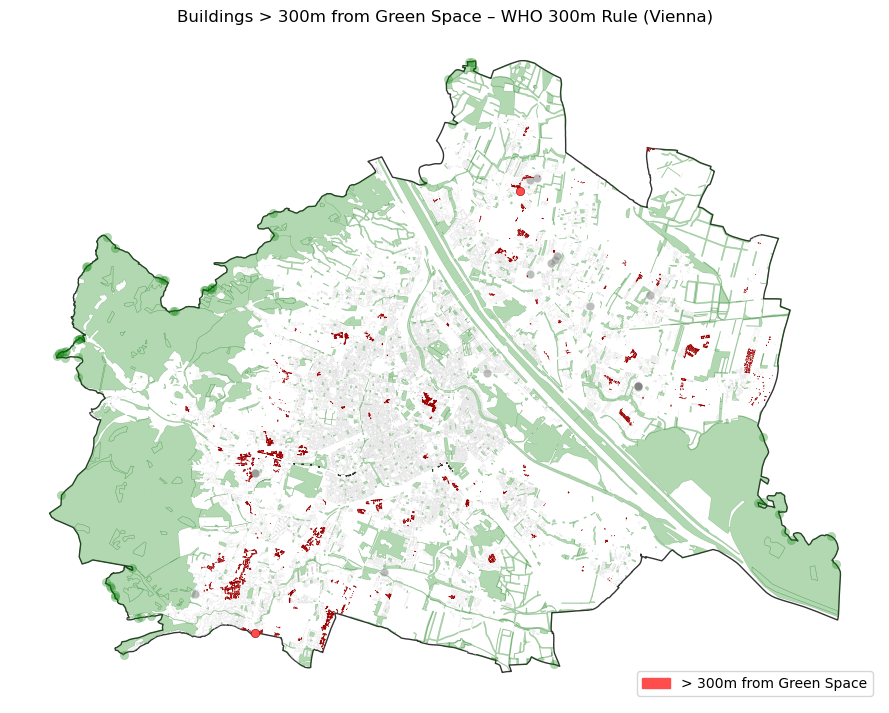

In [50]:
# import matplotlib.patches as mpatches

# Clip green areas to Vienna for clean plot
green_clipped = gpd.clip(green_proj, vienna_gdf_proj)

# Get non-compliant buildings
non_compliant_buildings = residential_vienna[~res_centroids['within_300m'].values]

# Create the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Plot layers
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)  # Green areas
residential_vienna.plot(ax=ax, color='grey', alpha=0.5, edgecolor='white', linewidth=0.2) # Residential buildings
non_compliant_buildings.plot(ax=ax, color='#FF4C4C', edgecolor='#990000', linewidth=0.4)  # Non-compliant

# Legend
legend_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
plt.legend(handles=[legend_patch], loc='lower right')

# Title and export
plt.title("Buildings > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/vienna_who_300m_noncompliant_only_legend.png", dpi=300, bbox_inches='tight')
plt.show()

In [51]:
def split_poly_to_hexagons(admin_gdf, resolution, crs):
    
    coords = list(admin_gdf.geometry.to_list()[0].exterior.coords)
    admin_geojson = {"type": "Polygon",  "coordinates": [coords]}
    hexagons = h3.polyfill(admin_geojson, 
                           resolution, 
                           geo_json_conformant=True)
    
    hexagon_geometries = {hex_id: Polygon(h3.h3_to_geo_boundary(hex_id, \
                                geo_json=True)) for hex_id in hexagons}
    gdf_hexagon_geometries = gpd.GeoDataFrame(hexagon_geometries.items(), 
                                    columns=['hex_id', 'geometry'])
    gdf_hexagon_geometries.crs = crs
    
    return gdf_hexagon_geometries

In [52]:
# Generate H3 hexagons for Vienna
vienna_proj = vienna_gdf.to_crs(epsg=4326)
hex_gdf = split_poly_to_hexagons(vienna_proj, resolution=9, crs="EPSG:4326")

# Reproject hexes and non-compliant buildings
hex_gdf_proj = hex_gdf.to_crs(epsg=31256)
noncompliant_proj = residential_vienna[~res_centroids['within_300m'].values]
noncompliant_proj = noncompliant_proj.to_crs(epsg=31256)

# Spatial join – assign buildings to H3 hexagons
join_hex = gpd.sjoin(hex_gdf_proj, noncompliant_proj, how="left", predicate="contains")

# Count buildings per hex
counts = join_hex.groupby('hex_id').size()
hex_gdf_proj['noncompliant_count'] = hex_gdf_proj['hex_id'].map(counts).fillna(0)

fig, ax = plt.subplots(figsize=(9, 9))
hex_gdf_proj.plot(
    ax=ax,
    column='noncompliant_count',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': 'Non-Compliant Buildings per Hex', 'shrink': 0.7}
)
green_clipped = gpd.clip(green_proj, vienna_gdf_proj)
green_clipped.plot(ax=ax, color='#90EE90', alpha=0.2)
vienna_gdf_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)

red_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
plt.legend(handles=[red_patch], loc='lower right')

plt.title('WHO 300m Rule – Non-Compliant Buildings (H3 Hex Map)', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.savefig('output/vienna_noncompliant_h3_hexmap.png', dpi=300, bbox_inches='tight')
plt.show()

AttributeError: module 'h3' has no attribute 'polyfill'

In [53]:
# Spatial join to assign each building to its district
districts_proj = districts.to_crs(epsg=31256)
res_with_district = gpd.sjoin(res_centroids, districts_proj[['NAMEK', 'geometry']], how='left', predicate='within')

# Group by district and summarize WHO compliance
district_summary = (
    res_with_district
    .groupby('NAMEK')
    .agg(
        total_buildings=('within_300m', 'count'),
        compliant_buildings=('within_300m', 'sum')
    )
    .assign(percent_compliant=lambda df: 100 * df['compliant_buildings'] / df['total_buildings'])
    .sort_values(by='percent_compliant', ascending=False)
)


Citywide non-compliance rate: 5.92%


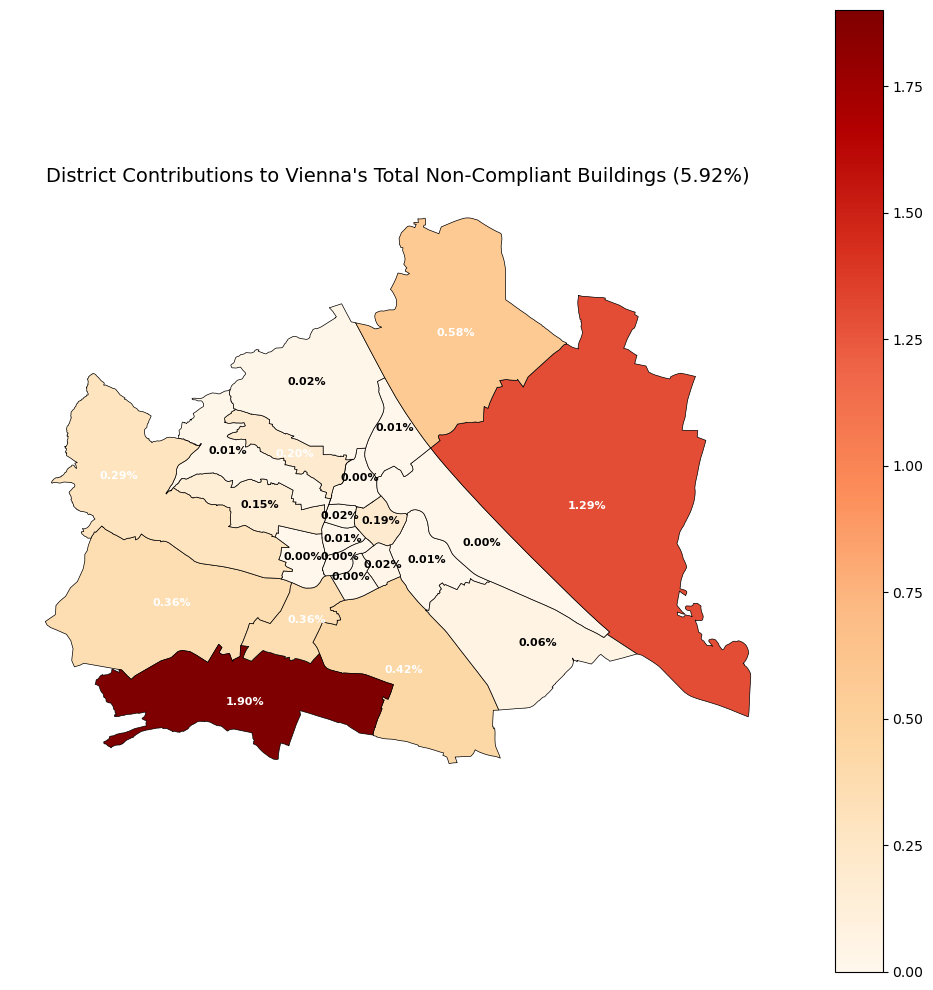

In [54]:
# Reset and calculate district-level non-compliance
district_summary = district_summary.reset_index()
district_summary['noncompliant_buildings'] = (
    district_summary['total_buildings'] - district_summary['compliant_buildings']
)

# Calculate citywide non-compliance percent
citywide_total = district_summary['total_buildings'].sum()
citywide_compliant = district_summary['compliant_buildings'].sum()
citywide_noncompliant = citywide_total - citywide_compliant
citywide_noncompliance_percent = (citywide_noncompliant / citywide_total) * 100
print(f"Citywide non-compliance rate: {citywide_noncompliance_percent:.2f}%")

# Scale district values to match citywide % total
district_summary['noncompliant_share_scaled'] = (
    district_summary['noncompliant_buildings'] / citywide_noncompliant * citywide_noncompliance_percent
)

# Merge with spatial data
districts_cityshare = districts.merge(
    district_summary[['NAMEK', 'noncompliant_share_scaled']], on='NAMEK'
)
districts_cityshare = districts_cityshare.to_crs(epsg=31256)


fig, ax = plt.subplots(figsize=(10, 10))
districts_cityshare.plot(
    ax=ax,
    column='noncompliant_share_scaled',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

districts_cityshare['label_point'] = districts_cityshare.representative_point()
for _, row in districts_cityshare.iterrows():
    ax.text(
        row['label_point'].x,
        row['label_point'].y,
        f"{row['noncompliant_share_scaled']:.2f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['noncompliant_share_scaled'] < 0.2 else 'white',
        weight='bold'
    )

plt.title(f"District Contributions to Vienna's Total Non-Compliant Buildings ({citywide_noncompliance_percent:.2f}%)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/vienna_noncompliance_contribution_scaled_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [55]:
# Calculate non-compliance % within each district
district_summary['percent_noncompliant'] = 100 - district_summary['percent_compliant']
district_summary = district_summary.reset_index()  # Make NAMEK a column

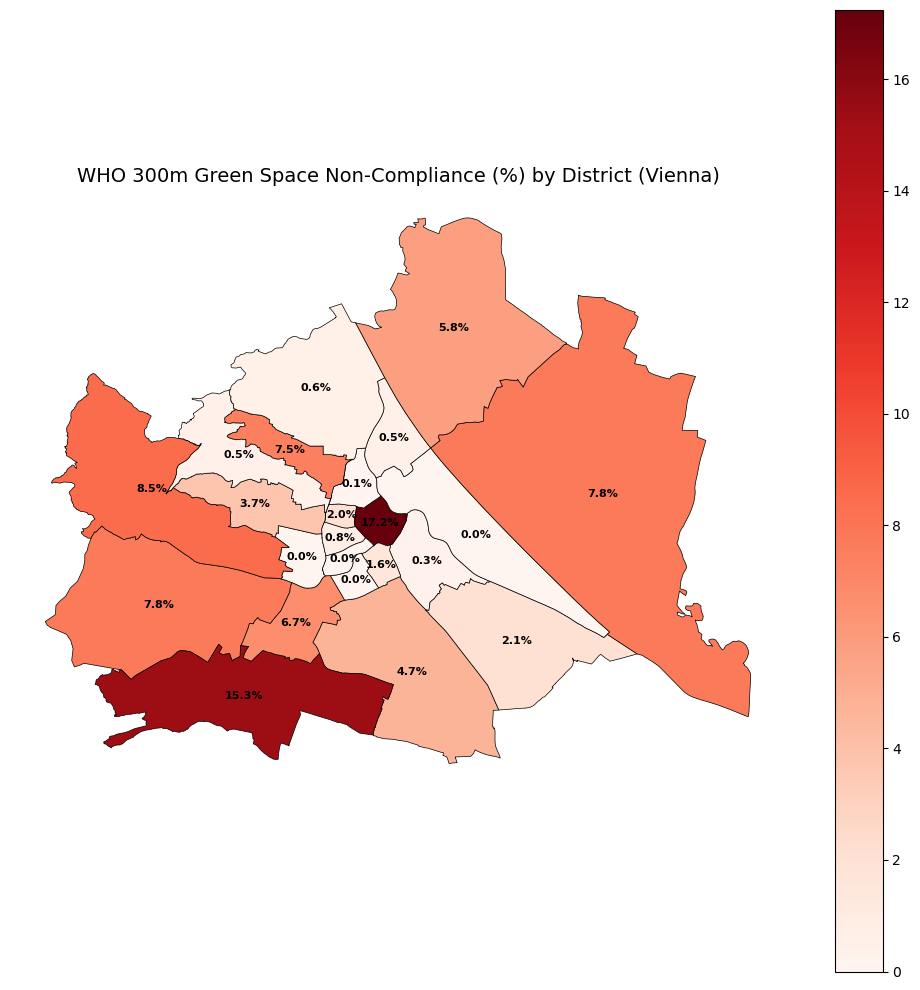

In [56]:
# Merge with districts GeoDataFrame
districts_plot = districts.merge(district_summary, on='NAMEK')
districts_plot = districts_plot.to_crs(epsg=31256)

# Get label positions (centroids)
districts_plot['centroid'] = districts_plot.geometry.centroid
districts_plot['label_x'] = districts_plot.centroid.x
districts_plot['label_y'] = districts_plot.centroid.y

fig, ax = plt.subplots(figsize=(10, 10))
districts_plot.plot(
    ax=ax,
    column='percent_noncompliant',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

for idx, row in districts_plot.iterrows():
    ax.text(
        row['label_x'],
        row['label_y'],
        f"{row['percent_noncompliant']:.1f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['percent_noncompliant'] < 50 else 'white',
        weight='bold'
    )

plt.title("WHO 300m Green Space Non-Compliance (%) by District (Vienna)", fontsize=14)
plt.axis('off')
plt.tight_layout()

plt.savefig("output/vienna_who_noncompliance_labeled_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [57]:
# import os
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import osmnx as ox
# from shapely.ops import unary_union

# Build target_districts from previous summary
# Only districts with at least one non-compliant building
noncompliant_districts = district_summary[district_summary['noncompliant_buildings'] > 0]

# Generate dynamic district list: {index: name}
target_districts = {i + 1: name for i, name in enumerate(noncompliant_districts['NAMEK'])}
print("Target districts with non-compliant buildings:", target_districts)

Target districts with non-compliant buildings: {1: 'Alsergrund', 2: 'Landstraße', 3: 'Brigittenau', 4: 'Hernals', 5: 'Döbling', 6: 'Neubau', 7: 'Wieden', 8: 'Josefstadt', 9: 'Simmering', 10: 'Ottakring', 11: 'Favoriten', 12: 'Floridsdorf', 13: 'Meidling', 14: 'Währing', 15: 'Donaustadt', 16: 'Hietzing', 17: 'Penzing', 18: 'Liesing', 19: 'Innere Stadt'}



 Processing District: Alsergrund
Total buildings: 1131
Within 300m: 1125
Compliant: 99.47%


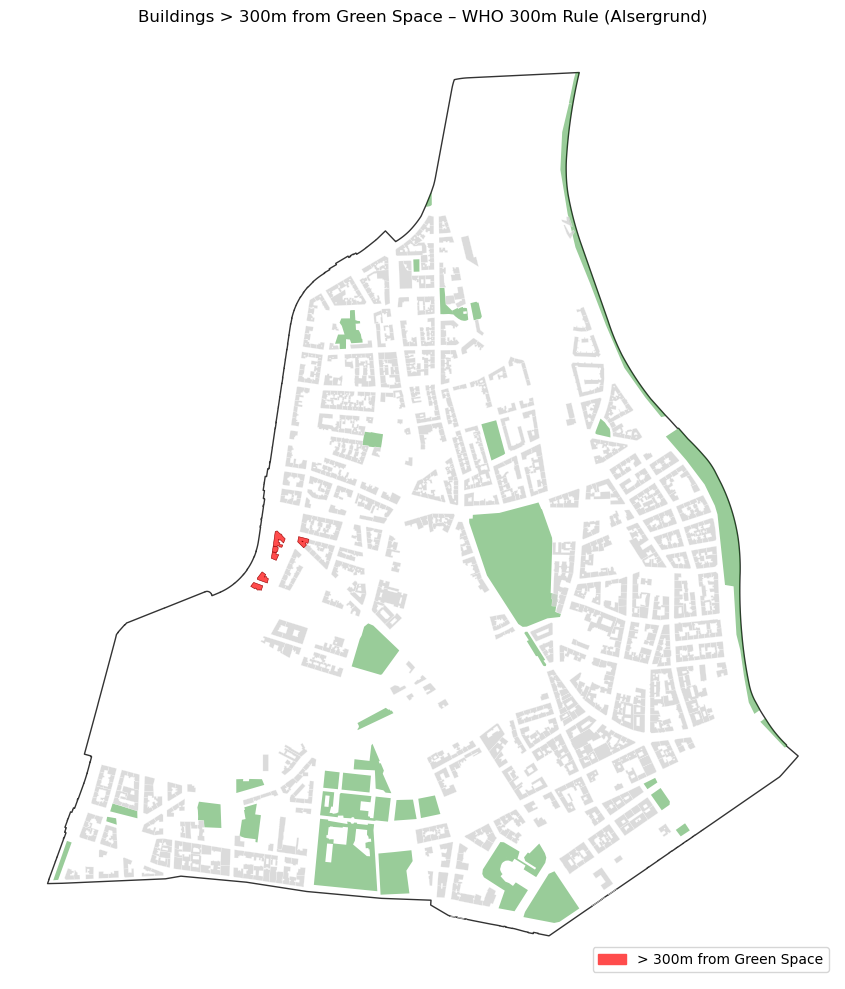


 Processing District: Landstraße
Total buildings: 2482
Within 300m: 2474
Compliant: 99.68%


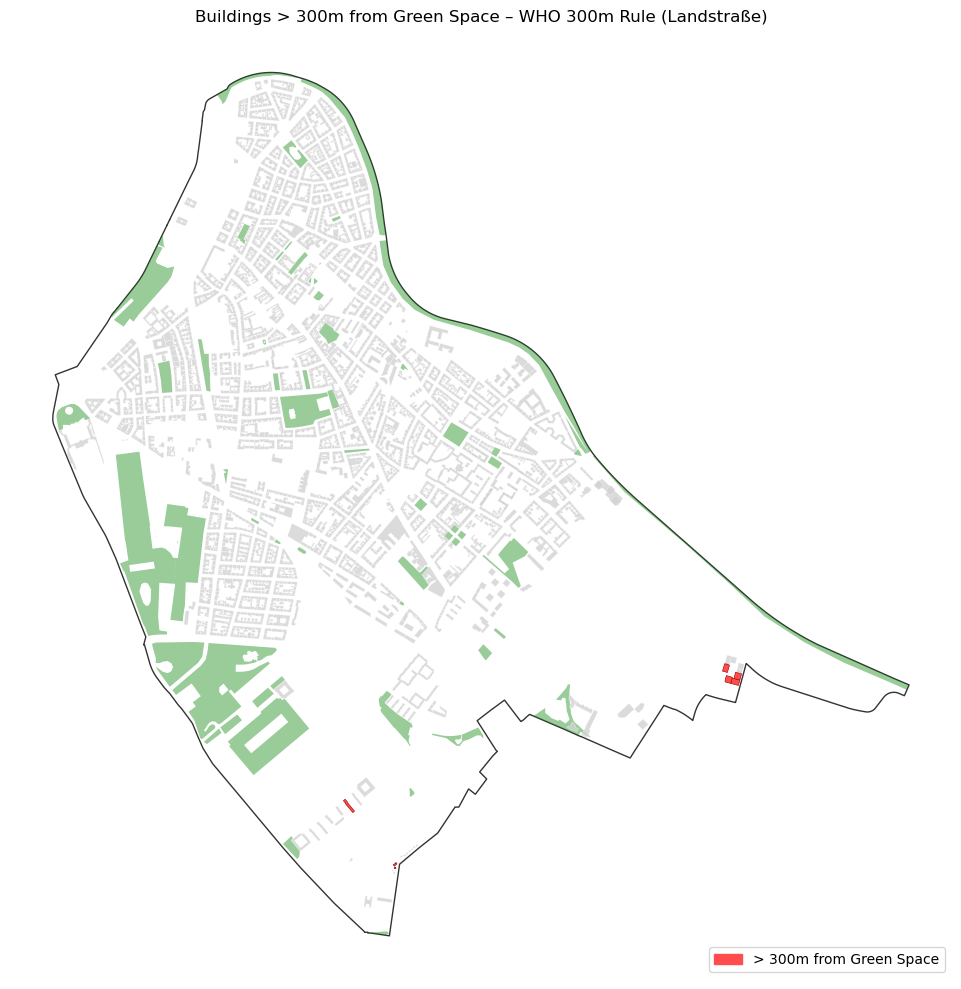


 Processing District: Brigittenau
Total buildings: 1326
Within 300m: 1318
Compliant: 99.40%


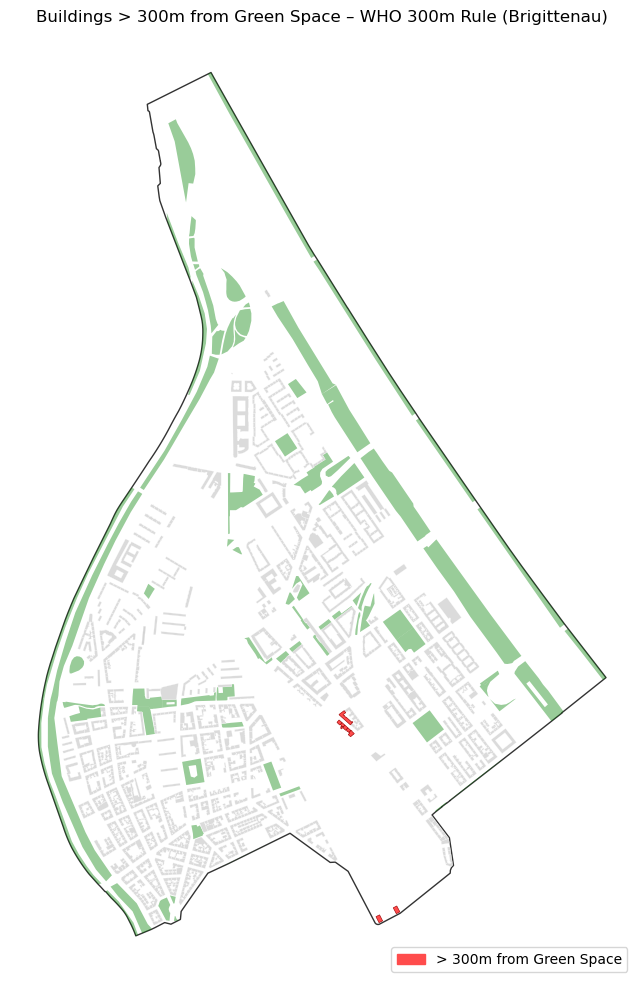


 Processing District: Hernals
Total buildings: 1893
Within 300m: 1753
Compliant: 92.60%


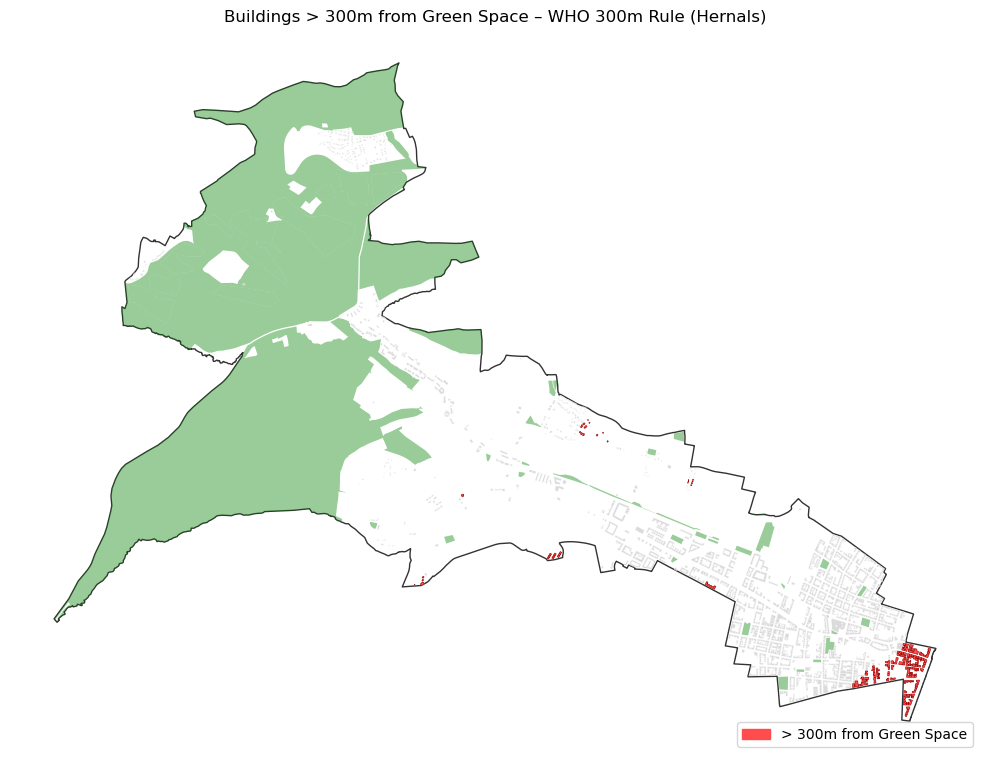


 Processing District: Döbling
Total buildings: 2426
Within 300m: 2364
Compliant: 97.44%


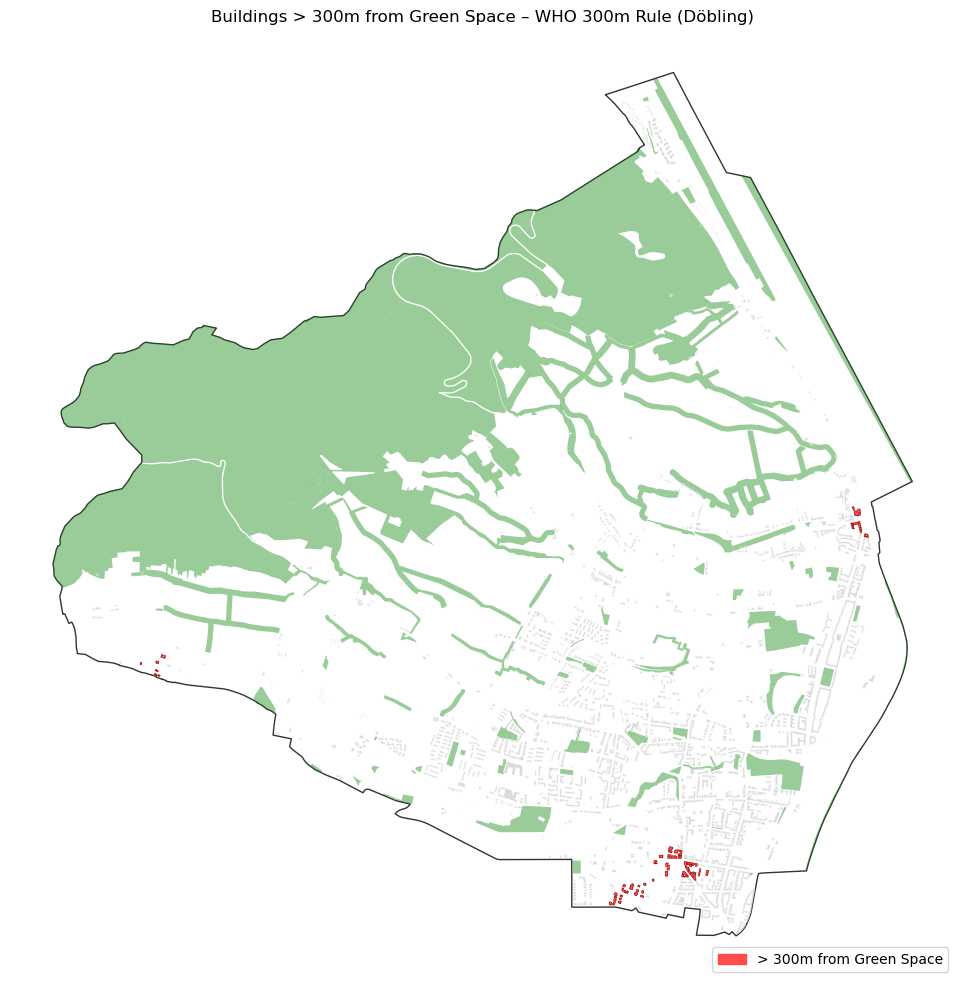


 Processing District: Neubau
Total buildings: 1126
Within 300m: 1109
Compliant: 98.49%


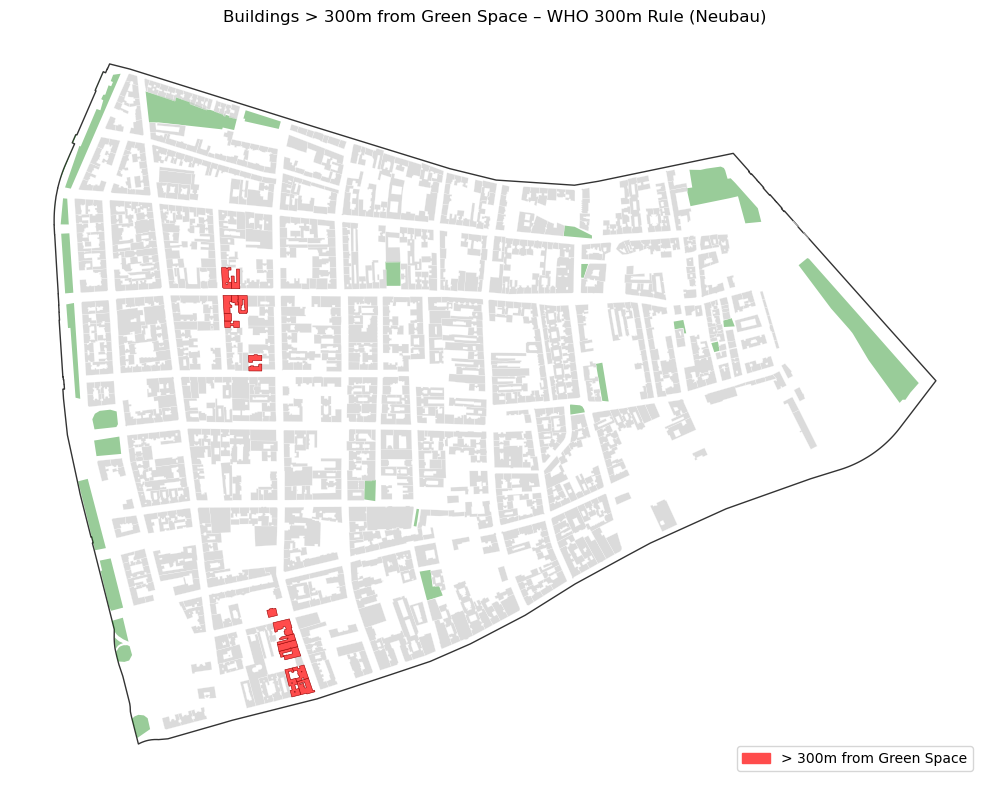


 Processing District: Wieden
Total buildings: 959
Within 300m: 927
Compliant: 96.66%


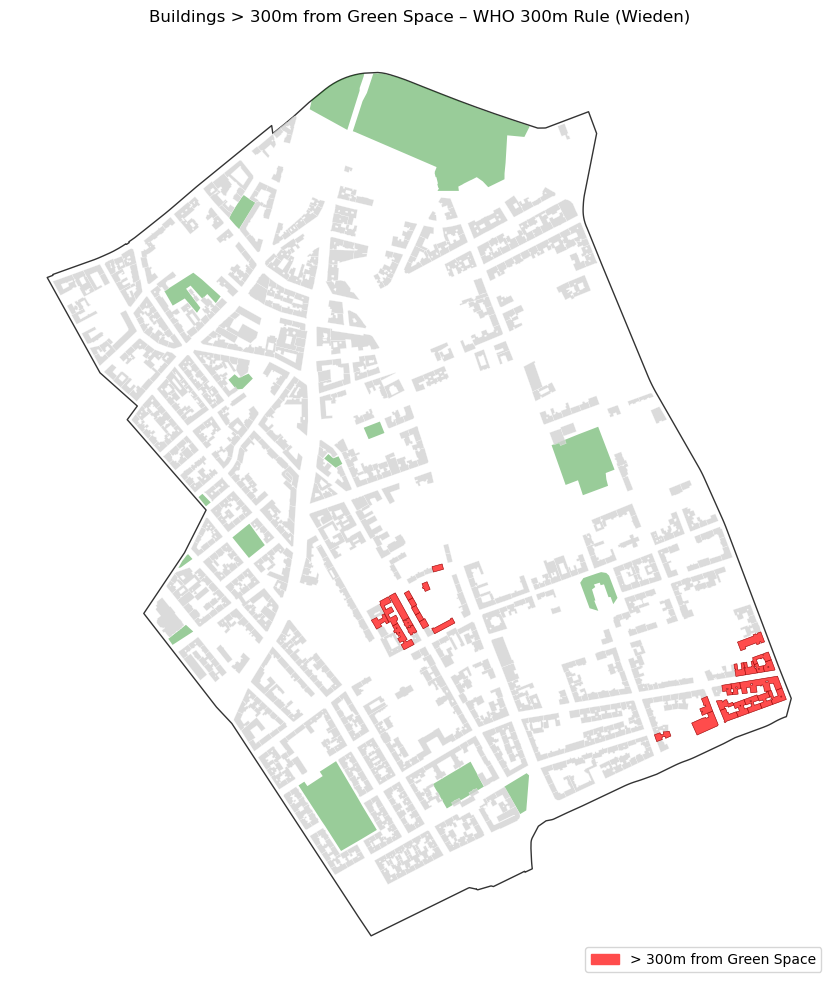


 Processing District: Josefstadt
Total buildings: 691
Within 300m: 616
Compliant: 89.15%


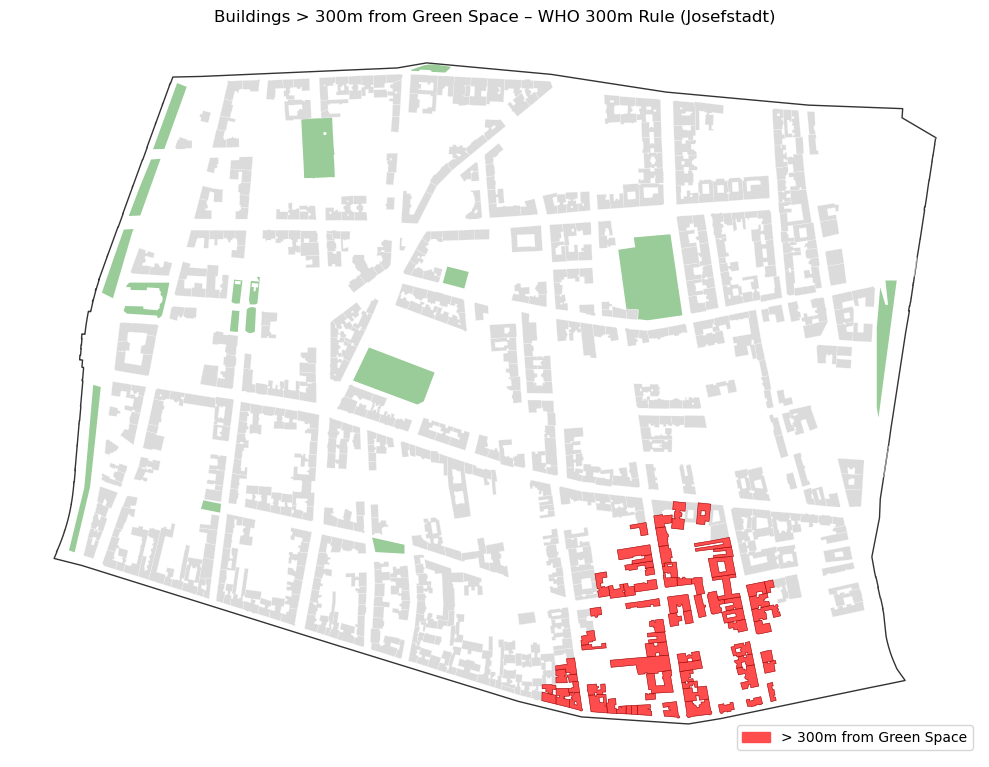


 Processing District: Simmering
Total buildings: 1771
Within 300m: 1726
Compliant: 97.46%


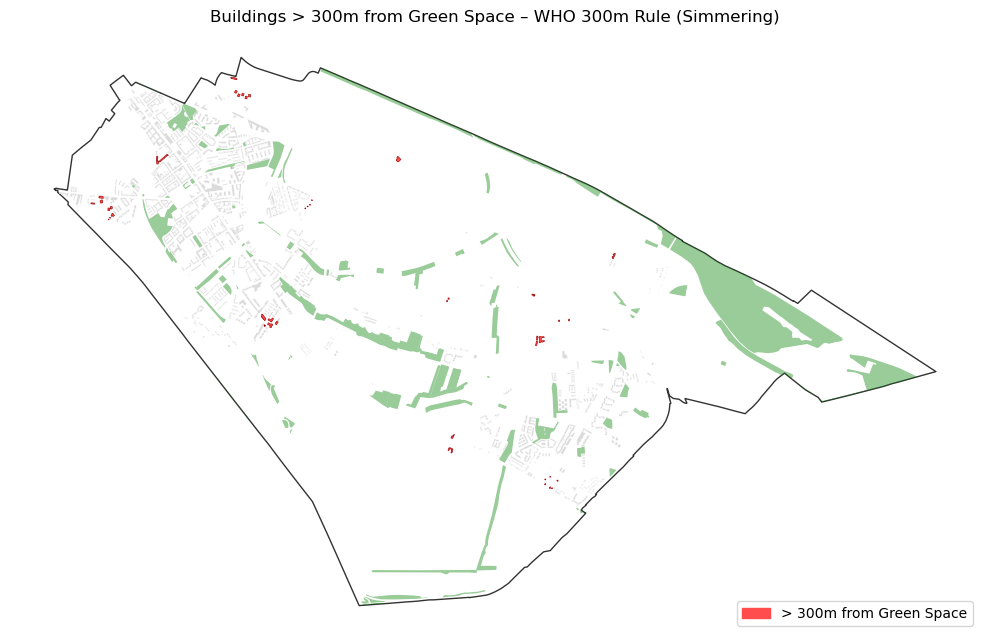


 Processing District: Ottakring
Total buildings: 2705
Within 300m: 2447
Compliant: 90.46%


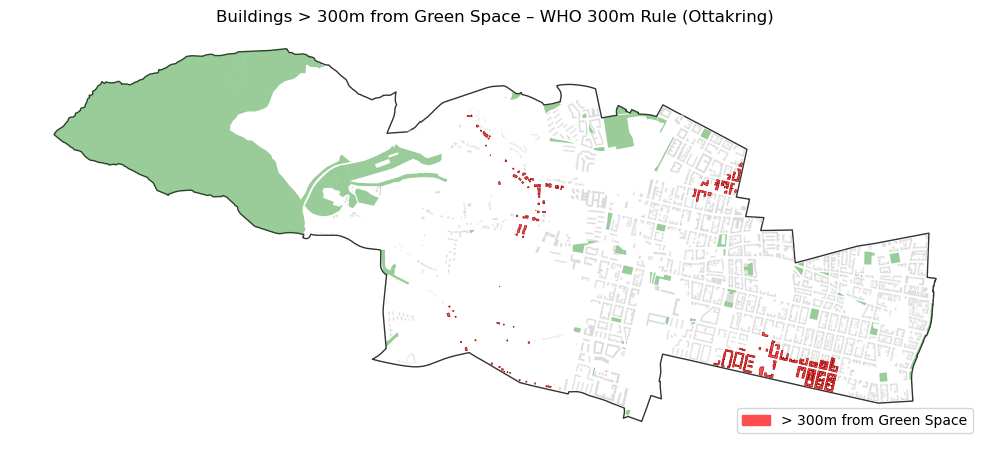


 Processing District: Favoriten
Total buildings: 6076
Within 300m: 5762
Compliant: 94.83%


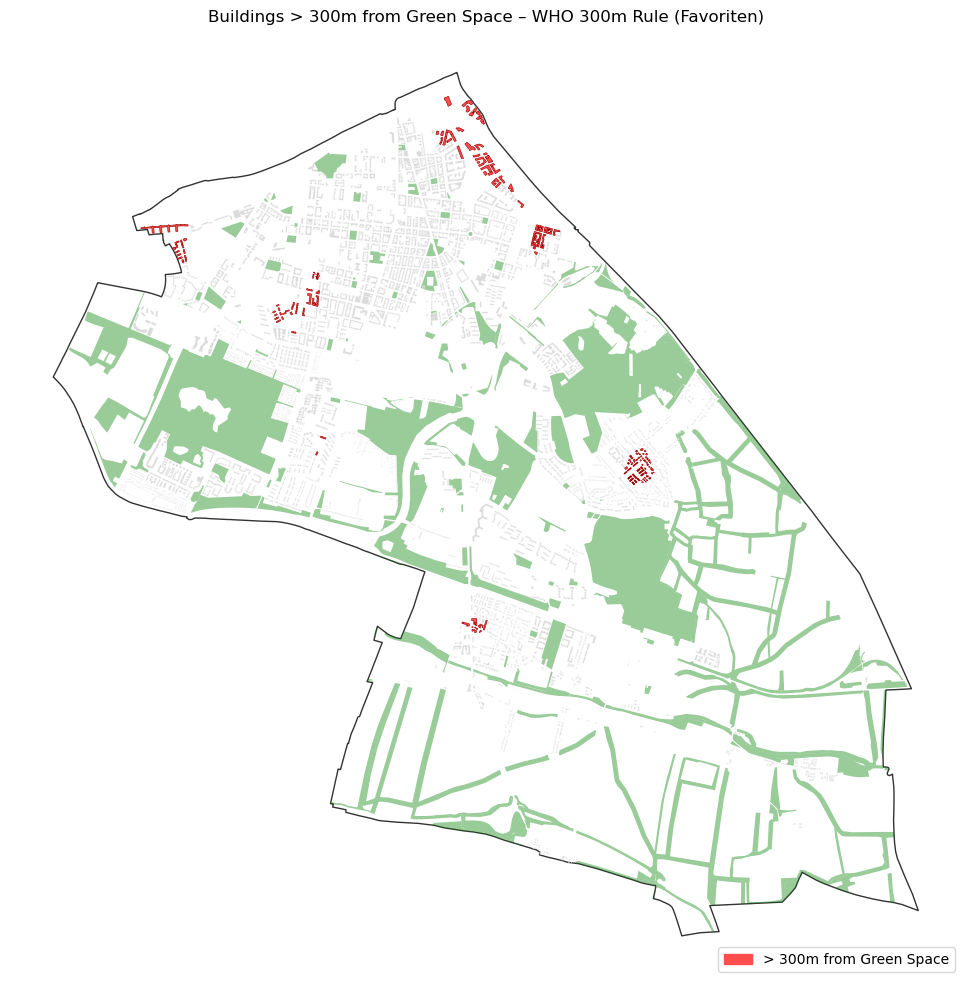


 Processing District: Floridsdorf
Total buildings: 6606
Within 300m: 6171
Compliant: 93.42%


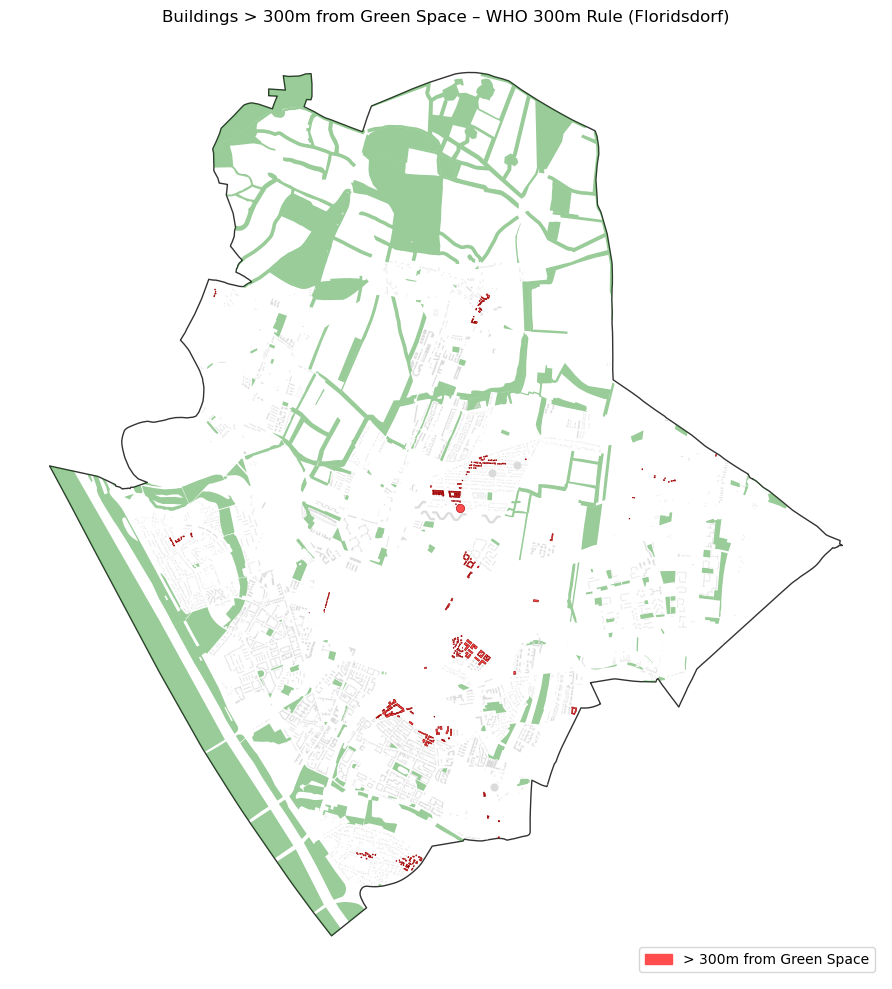


 Processing District: Meidling
Total buildings: 3587
Within 300m: 3217
Compliant: 89.68%


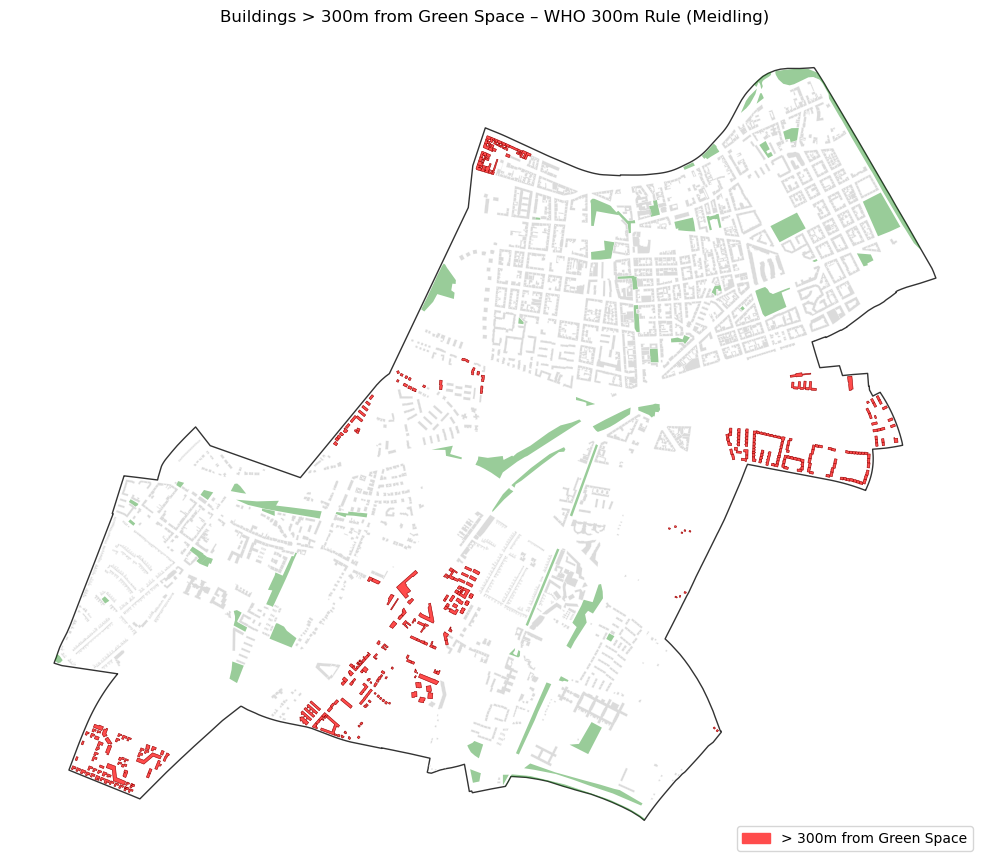


 Processing District: Währing
Total buildings: 1789
Within 300m: 1630
Compliant: 91.11%


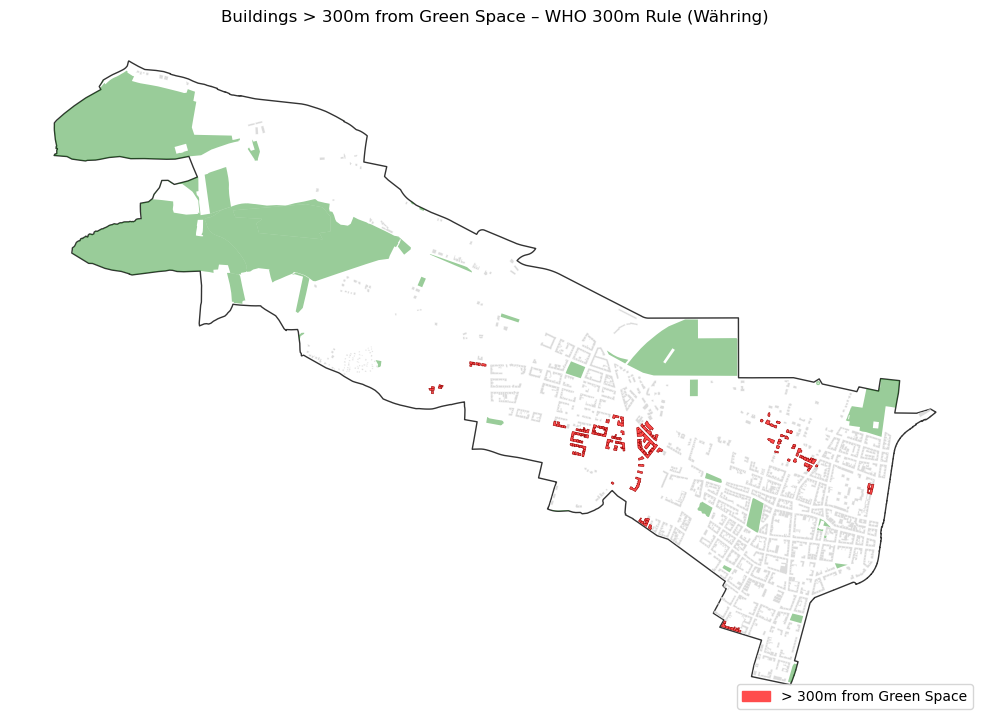


 Processing District: Donaustadt
Total buildings: 11099
Within 300m: 10214
Compliant: 92.03%


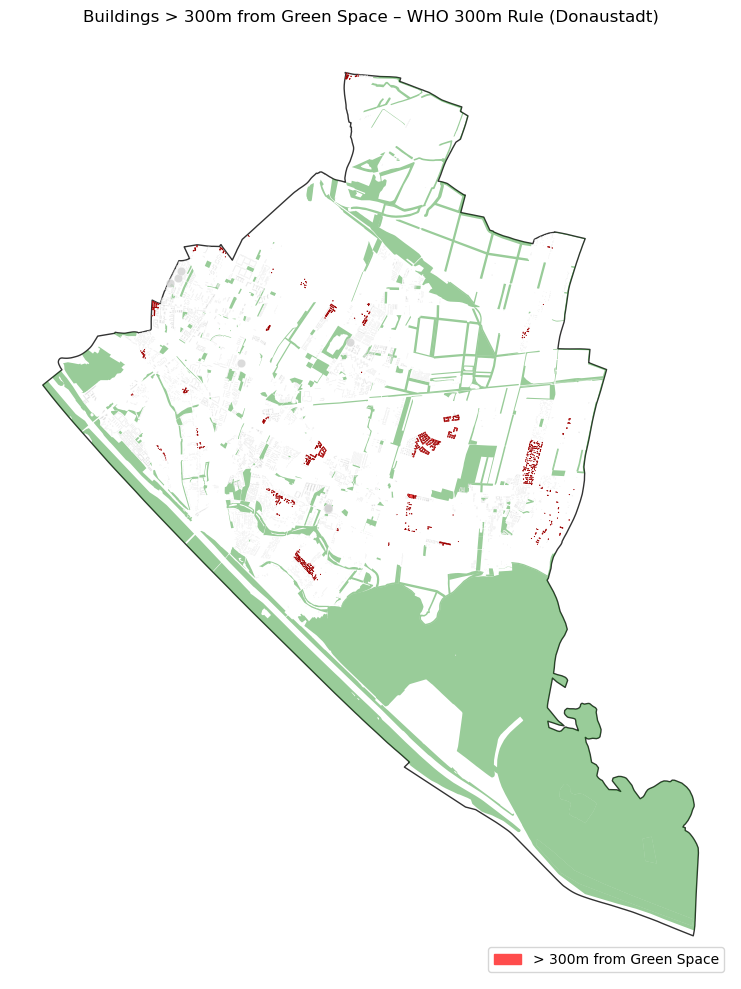


 Processing District: Hietzing
Total buildings: 3107
Within 300m: 2865
Compliant: 92.21%


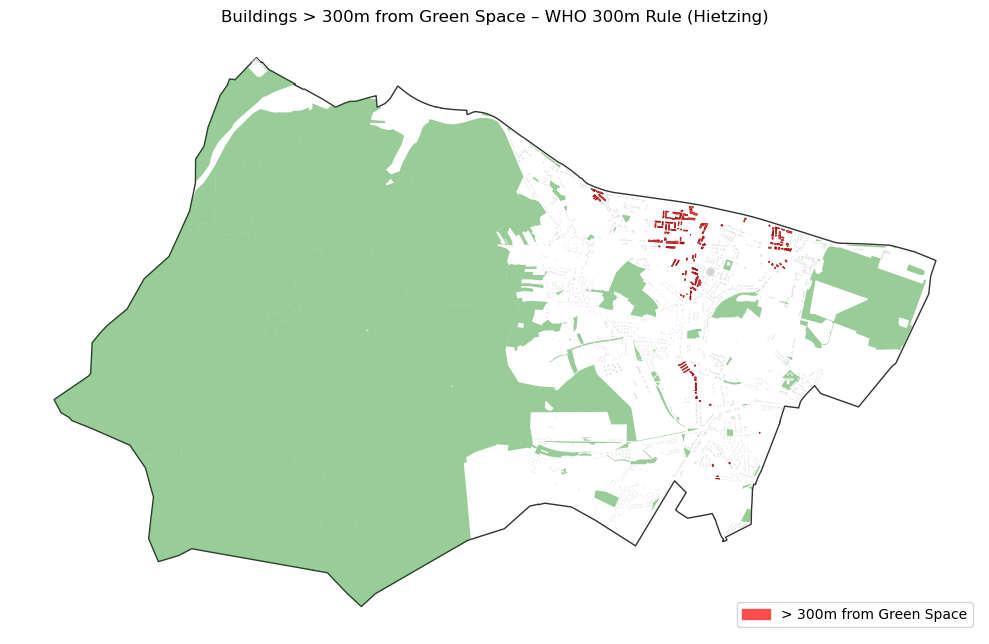


 Processing District: Penzing
Total buildings: 2275
Within 300m: 2062
Compliant: 90.64%


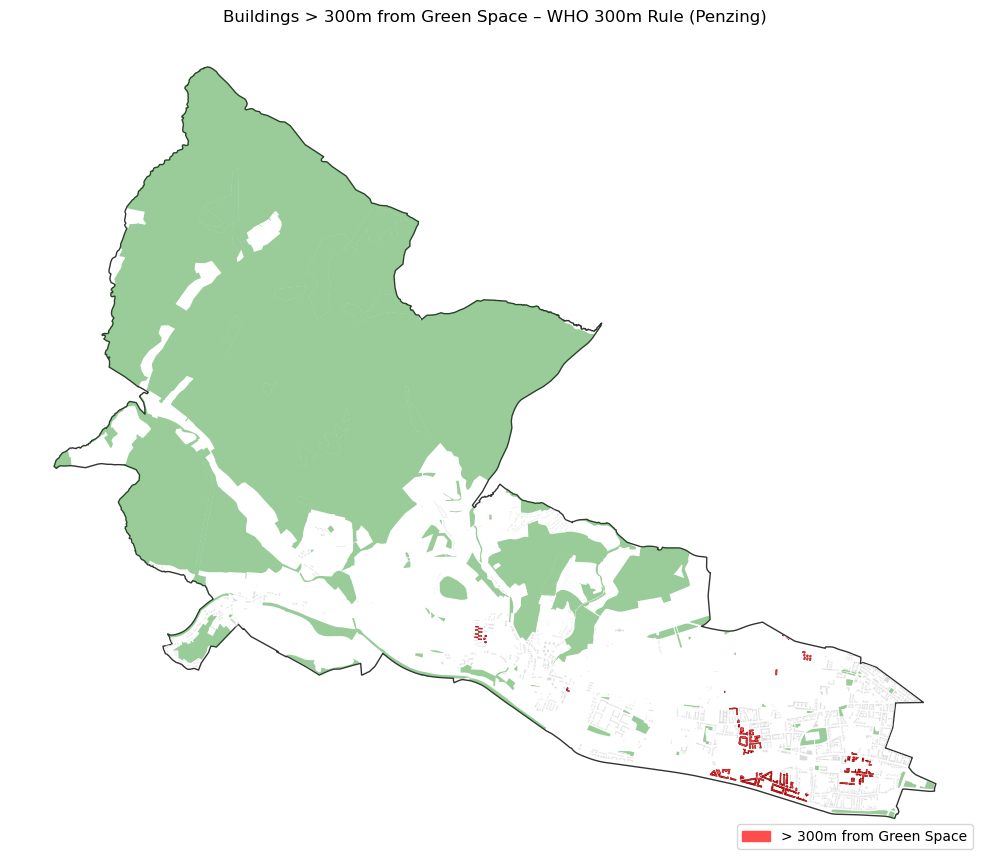


 Processing District: Liesing
Total buildings: 8290
Within 300m: 6919
Compliant: 83.46%


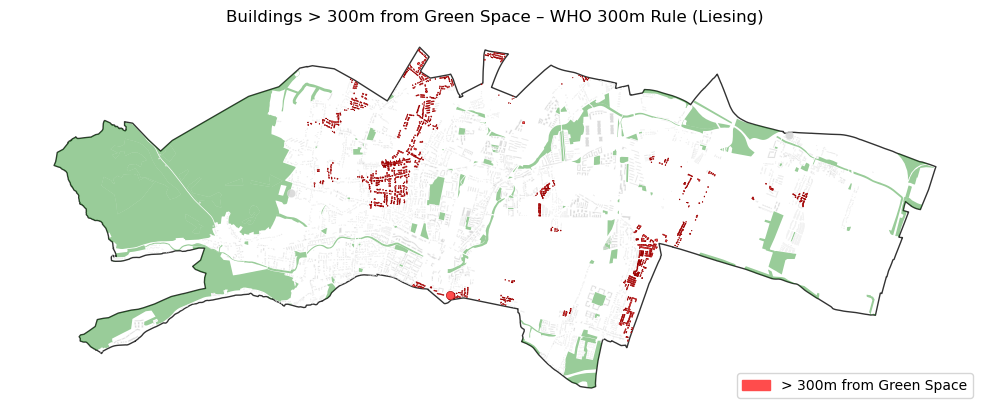


 Processing District: Innere Stadt
Total buildings: 749
Within 300m: 618
Compliant: 82.51%


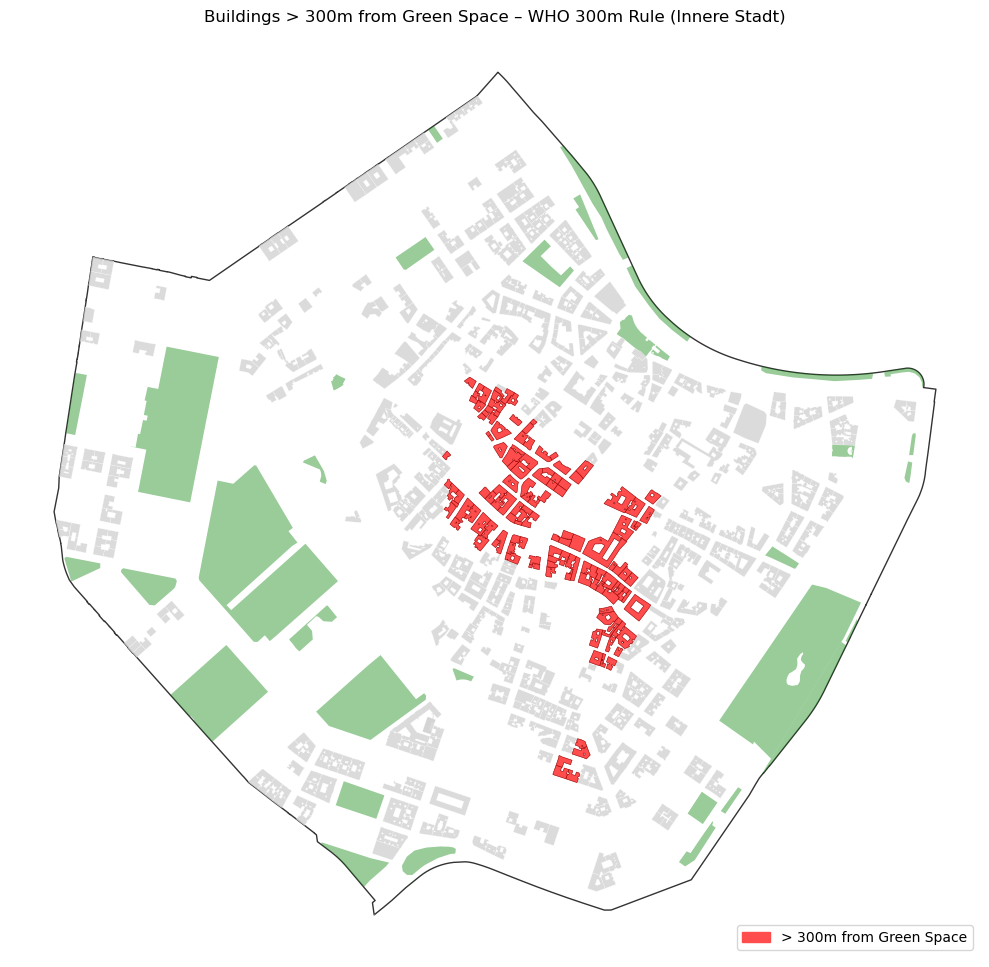

In [58]:
for num, name in target_districts.items():
    print(f"\n Processing District: {name}")

    # Filter district geometry
    district = districts[districts['NAMEK'] == name]
    if district.empty:
        print(f"District '{name}' not found.")
        continue

    # Align CRS
    residential = residential.to_crs(district.crs)
    green = gdf_green.to_crs(district.crs)

    # Clip buildings and green areas to the district
    residential_clipped = gpd.clip(residential, district)
    green_clipped = gpd.clip(green, district)

    # Reproject everything to EPSG:31256
    crs_proj = 31256
    residential_proj = residential_clipped.to_crs(epsg=crs_proj)
    green_proj = green_clipped.to_crs(epsg=crs_proj)
    district_proj = district.to_crs(epsg=crs_proj)

    # Calculate centroids
    res_centroids = residential_proj.copy()
    res_centroids['geometry'] = res_centroids.centroid

    # Create unified green geometry
    green_union = unary_union(green_proj.geometry)

    # Distance calculation
    res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
    res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

    # Basic stats
    total = len(res_centroids)
    within = res_centroids['within_300m'].sum()
    percent = (within / total) * 100 if total > 0 else 0

    print(f"Total buildings: {total}")
    print(f"Within 300m: {within}")
    print(f"Compliant: {percent:.2f}%")

    # Identify non-compliant buildings
    non_compliant_buildings = residential_proj[~res_centroids['within_300m'].values]

    # Plot and Save
    fig, ax = plt.subplots(figsize=(10, 10))
    district_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
    green_proj.plot(ax=ax, color='green', alpha=0.4)  # Green spaces
    residential_proj.plot(ax=ax, color='#D3D3D3', alpha=0.8, edgecolor='white', linewidth=0.2)  # All buildings
    non_compliant_buildings.plot(ax=ax, color='#FF4C4C', edgecolor='#990000', linewidth=0.4)  # Non-compliant

    # Custom legend fix
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
    plt.legend(handles=[red_patch], loc='lower right')

    # Final touches
    plt.title(f"Buildings > 300m from Green Space – WHO 300m Rule ({name})", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    filename = f"output/who_noncompliant_{name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

